# Stimulus Regression Analysis with Adaptive Latents

This notebook recreates the functionality of the `learn_s_hat_toy.py` and adds functionality for an adaptive regressor. 



In [151]:
#Import Required Libraries
import sys
sys.path.append("/home/patriciobarber/AdaptiveLatents")
import itertools
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import warnings
import jax
from jax import numpy as jnp

from adaptive_latents.input_sources.lds_simulation import LDS
from adaptive_latents import StreamingKalmanFilter, ArrayWithTime, Pipeline, StimRegressor, Bubblewrap
from adaptive_latents.regressions import BaseMultiKernelRegressor
import tqdm.auto as tqdm

# Import plotting functions (you may need to modify the import path)
try:
    from simulation_plots.learn_s_hat_plots import finalize_log, plot_onestep_pred_error_decreasing, make_table, plot_manifold_error
except ImportError:
    print("Warning: Could not import plotting functions. You may need to implement these functions or adjust the import path.")


In [152]:
# Define Constants and Configuration
standard_kinds_of_sr = ['learning from stim', 'ignoring stim samples', 'unaware of stim']
time_slices = ('post-stim', 'non-stim', 'all')
space_slices = ('stim-d', 'non-stim-d', 'all')

# Simulation parameters
n_rotations = 20
noise_variance = 0.05
stims_per_rotation = 1
stim_magnitude = 10

print(f"Configuration set:")
print(f"- Rotations: {n_rotations}")
print(f"- Noise variance: {noise_variance}")
print(f"- Stimulations per rotation: {stims_per_rotation}")
print(f"- Stimulation magnitude: {stim_magnitude}")
print(f"- Stimulus regressor types: {standard_kinds_of_sr}")

Configuration set:
- Rotations: 20
- Noise variance: 0.05
- Stimulations per rotation: 1
- Stimulation magnitude: 10
- Stimulus regressor types: ['learning from stim', 'ignoring stim samples', 'unaware of stim']


In [153]:
# Custom StimRegressor Class with Extra Logging
class StimRegressorWithExtraLogging(StimRegressor):
    """Extended StimRegressor that logs additional s_hat error information and bandwidth tracking."""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.s_hat_error_function = None

    def pre_log(self, data, stream):
        """Log s_hat error if conditions are met."""
        if self.log_level >= 2 and self.dt is not None:
            if (self.input_streams[stream] == 'X' and 
                len(self.get_stim_to_correct_for(data.t)) and 
                self.s_hat_error_function is not None):
                
                key = 's_hat_error'
                if key not in self.log:
                    self.log[key] = []
                self.log[key].append(
                    ArrayWithTime.from_transformed_data(self.s_hat_error_function(self), data)
                )
            
            # Track bandwidth at every X timestep if stim_reg has tracking capability
            if (self.input_streams[stream] == 'X' and 
                hasattr(self.stim_reg, 'track_bandwidth_at_state')):
                try:
                    self.stim_reg.track_bandwidth_at_state(data.data)
                except Exception as e:
                    pass  # Silently ignore tracking errors

    def partial_fit_transform(self, data, stream=0, return_output_stream=False):
        """Override to include pre-logging."""
        self.pre_log(data, stream)
        return super().partial_fit_transform(data, stream=stream, return_output_stream=return_output_stream)

print("StimRegressorWithExtraLogging class defined successfully!")

StimRegressorWithExtraLogging class defined successfully!


In [154]:
# Helper Functions for Data Processing

def make_slices_tensor(sr):
    """Create slices of prediction errors across time and space dimensions."""
    error = sr.log['pred_error']
    stim_intended_samples = sr.log['stim_intended_samples']

    outputs = []
    index_one = []
    index_two = []

    for i, time_slice in enumerate(time_slices):
        # Time slicing
        if time_slice == 'post-stim':
            _, value = ArrayWithTime.align_indices(stim_intended_samples, error)
        elif time_slice == 'non-stim':
            _, value = ArrayWithTime.align_indices(stim_intended_samples, error, complement=True)
        elif time_slice == 'all':
            value = error
        else:
            raise ValueError(f"Unknown time slice: {time_slice}")

        for j, space_slice in enumerate(space_slices):
            # Space slicing
            if space_slice == 'stim-d':
                value2 = value[:,2:3]  # Stimulation dimension
            elif space_slice == 'non-stim-d':
                value2 = value[:,:2]   # Non-stimulation dimensions
            elif space_slice == 'all':
                value2 = value
            else:
                raise ValueError(f"Unknown space slice: {space_slice}")

            outputs.append(value2)
            index_one.append(time_slice)
            index_two.append(space_slice)
            
    outputs = pd.Series(outputs, index=[np.array(index_one), np.array(index_two)])
    return outputs

print("Data processing helper functions defined successfully!")

Data processing helper functions defined successfully!


In [155]:
# Ideal Model Creation Functions

def make_ideal_nostim_srs(rng, n_runs=1, streaming=False, show_tqdm=False):
    """Create ideal stimulus regressors without stimulation for baseline comparison."""
    ideal_srs = []
    
    for _ in tqdm.trange(n_runs, disable=not show_tqdm, desc="Creating ideal models"):
        if not streaming:
            # Non-streaming version
            X, Y, stim = LDS.run_nest_dynamical_system(
                n_rotations, 
                stims_per_rotation=stims_per_rotation, 
                stim_magnitude=0,  # No stimulation for ideal case
                rng=rng, 
                u_function='curvy', 
                noise=noise_variance
            )
            kf = StreamingKalmanFilter(steps_between_refits=float('inf'))
            kf.fit(Y, Y)
            
            sr_ideal = StimRegressor(autoreg=kf, log_level=2, check_dt=True)
            sr_ideal.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
            ideal_srs.append(finalize_log(sr_ideal, stim))
        else:
            # Streaming version
            sr_ideal = StimRegressor(autoreg=StreamingKalmanFilter(), log_level=2, check_dt=True)
            _, Y, stim = LDS.run_nest_dynamical_system(
                n_rotations, 
                stims_per_rotation=stims_per_rotation, 
                stim_magnitude=0,  # No stimulation for ideal case
                rng=rng, 
                u_function='curvy', 
                noise=noise_variance
            )
            sr_ideal.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
            ideal_srs.append(finalize_log(sr_ideal, stim))

    return ideal_srs

print("Ideal model creation functions defined successfully!")

Ideal model creation functions defined successfully!


In [156]:
# Stimulus Response Functions

def true_S(point):
    """Calculate the true stimulus response for a given point."""
    true = np.zeros(3)
    true[2] = stim_magnitude * point[0] / np.linalg.norm(point[:2])
    return true

def make_s_hat_error_function(rng, n_runs=10, n_points=200):
    """Create an error evaluation function based on test points from multiple runs."""
    # Generate test data from multiple runs
    previous_Ys = []
    for _ in range(n_runs):
        _, Y, stim = LDS.run_nest_dynamical_system(
            n_rotations, 
            stims_per_rotation=stims_per_rotation, 
            stim_magnitude=stim_magnitude, 
            rng=rng, 
            u_function='curvy', 
            noise=noise_variance
        )
        previous_Ys.append(Y)

    # Select random test points
    test_points = rng.choice(np.vstack(previous_Ys), replace=False, size=n_points)
    
    def s_hat_error_function(self):
        """Calculate mean error between predicted and true stimulus responses."""
        s_hat_errors = []
        for point in test_points:
            # Predict stimulus response and compare to ground truth
            predicted = self.stim_reg.predict(np.hstack([point, np.array([1])]))
            true_response = true_S(point)
            error = predicted - true_response
            s_hat_errors.append(error)
        
        return np.linalg.norm(s_hat_errors, axis=1).mean()

    return s_hat_error_function

print("Stimulus response functions defined successfully!")

Stimulus response functions defined successfully!


In [157]:
# Adaptive Multi-Kernel Regressor Implementation

class AdaptiveMultiKernelRegressor(BaseMultiKernelRegressor):
    """
    An implementation of BaseMultiKernelRegressor that stores adaptive bandwidth
    for EACH training point based on the local flow at that point.
    
    This makes it fundamentally different from the base regressor:
    - Base regressor: Uses fixed length scales for all training points
    - Adaptive regressor: Each training point has its own bandwidth based on local flow
    """
    def __init__(self, sigma_0, gamma, flow_vector_func, maxlen=100):
        """
        Initializes the adaptive regressor.

        Args:
            sigma_0 (float): The base bandwidth (sigma_0 in your formula).
            gamma (float): The scaling factor for the flow magnitude (gamma).
            flow_vector_func (callable): A function that takes an input vector 'x'
                                        and returns the flow vector 'V(x)'.
            maxlen (int): The maximum number of observations to store.
        """
        # Initialize parent with dummy length_scales since we'll compute them adaptively
        super().__init__(length_scales=(1.0,), maxlen=maxlen) 
        
        self.sigma_0 = sigma_0
        self.gamma = gamma
        self.flow_vector_func = flow_vector_func
        
        # NEW: Store bandwidth for each training point
        self.bandwidth_at_training_points = []
        
    def observe(self, x, y):
        """Override observe to calculate and store bandwidth at training time."""
        try:
            # Calculate flow and bandwidth at this training point
            # Handle different input formats (list of arrays, single array, etc.)
            if isinstance(x, (list, tuple)):
                full_x_vector = np.concatenate([np.array(sub_x).flatten() for sub_x in x])
            else:
                full_x_vector = np.array(x).flatten()
            
            # Convert to JAX array for flow function
            full_x_vector_jax = jnp.array(full_x_vector)
            flow_vector = self.flow_vector_func(full_x_vector_jax)
            
            # Convert back to numpy for calculations
            flow_vector_np = np.array(flow_vector)
            flow_magnitude = np.linalg.norm(flow_vector_np)
            
            # Check for NaN or invalid values
            if np.isnan(flow_magnitude) or np.isinf(flow_magnitude):
                adaptive_bandwidth = self.sigma_0
            else:
                adaptive_bandwidth = self.sigma_0 / (1 + self.gamma * flow_magnitude)
            
            # Store the bandwidth for this training point
            self.bandwidth_at_training_points.append(float(adaptive_bandwidth))
            
            # Maintain maxlen
            if len(self.bandwidth_at_training_points) > self.maxlen:
                self.bandwidth_at_training_points.pop(0)
        except Exception as e:
            # Fallback to base bandwidth if flow calculation fails
            print(f"Warning in observe: {e}, using base bandwidth")
            self.bandwidth_at_training_points.append(float(self.sigma_0))
        
        # Call parent observe
        super().observe(x, y)

    def make_jax_pred_f(self):
        if self.input_histories is None or len(self.bandwidth_at_training_points) == 0:
            def f(x):
                return np.array([[np.nan]])
        else:
            input_histories = [jnp.array(h) for h in self.input_histories]
            output_history = jnp.array(self.output_history)
            
            # Convert stored bandwidths to length scales for each training point
            # Each training point gets its OWN length scale based on flow at that location
            training_length_scales = jnp.array([1.0 / (2 * bw**2) for bw in self.bandwidth_at_training_points])
            
            def f(x):
                try:
                    # Calculate distances using each training point's specific length scale
                    all_distances = []
                    
                    for hist_idx, history in enumerate(input_histories):
                        # For each input dimension's history
                        distances_for_dim = []
                        sub_x = jnp.array(x[hist_idx]).flatten()
                        
                        for point_idx in range(len(history)):
                            # Use the length scale that was computed at training time for THIS point
                            point_length_scale = training_length_scales[point_idx]
                            dist = -point_length_scale * jnp.linalg.norm(history[point_idx] - sub_x) ** 2
                            distances_for_dim.append(dist)
                        
                        all_distances.append(jnp.array(distances_for_dim))
                    
                    # Sum distances across all input dimensions
                    log_weights = jnp.array(all_distances).sum(axis=0)
                    log_weights = jnp.nan_to_num(log_weights, nan=-jnp.inf)
                    log_sum = jax.scipy.special.logsumexp(log_weights)
                    log_weights = log_weights - log_sum

                    return jnp.exp(log_weights) @ output_history
                except Exception as e:
                    # Return NaN array if prediction fails
                    return jnp.array([jnp.nan] * output_history.shape[1])
            return f

    def predict(self, x):
        try:
            pred_f = self.make_jax_pred_f()
            if pred_f is None:
                return np.array([np.nan])
            result = pred_f(x)
            return np.array(result)
        except Exception as e:
            # Return appropriate sized NaN array
            if self.output_history is not None:
                return np.array([np.nan] * self.output_history.shape[1])
            else:
                return np.array([np.nan])


def create_flow_vector_function():
    """
    Create a flow vector function based on the LDS dynamics.
    This is a simple example that could be replaced with a more sophisticated flow field.
    """
    def flow_vector_func(x):
        # Ensure x is a JAX array and handle different input sizes
        x = jnp.array(x)
        
        # Handle different input sizes - take first 3 dimensions as state
        if x.size >= 3:
            state_part = x[:3]  # Neural state dimensions
        else:
            # Pad with zeros if input is smaller
            state_part = jnp.concatenate([x, jnp.zeros(3 - x.size)])
        
        # Create a flow that varies with position (similar to curvy dynamics)
        flow = jnp.array([
            -state_part[1],  # Rotational component
            state_part[0],   # Rotational component  
            0.1 * state_part[2]  # Slower dynamics in stimulation dimension
        ])
        
        return flow
    
    return flow_vector_func

print("AdaptiveMultiKernelRegressor class defined successfully!")
print("✓ Key difference: Adaptive version stores bandwidth at EACH training point")
print("✓ Base regressor uses fixed length scales for all points")
print("✓ Adaptive regressor weights each point based on flow at its location")

AdaptiveMultiKernelRegressor class defined successfully!
✓ Key difference: Adaptive version stores bandwidth at EACH training point
✓ Base regressor uses fixed length scales for all points
✓ Adaptive regressor weights each point based on flow at its location


In [158]:
# Adaptive vs Base Kernel Regressor Comparison

def create_adaptive_comparison_srs(rng):
    """Create stimulus regressors comparing base and adaptive kernel methods."""
    # Generate synthetic neural data with stimulation
    _, Y, stim = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=stims_per_rotation, 
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='curvy', 
        noise=noise_variance
    )

    # Create flow vector function
    flow_func = create_flow_vector_function()

    # Create stimulus regressor with base multi-kernel regressor
    sr_base = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(length_scales=(1.0, 1.0, 1.0), maxlen=100), 
        log_level=2, 
        check_dt=True
    )
    
    # Create stimulus regressor with adaptive multi-kernel regressor
    sr_adaptive = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=AdaptiveMultiKernelRegressor(
            sigma_0=1.0,     # Base bandwidth
            gamma=0.5,       # Flow sensitivity
            flow_vector_func=flow_func,
            maxlen=100
        ), 
        log_level=2, 
        check_dt=True
    )

    # Run both regressors on the same data
    pre_srs = {
        'Base Kernel (learning from stim)': sr_base, 
        'Adaptive Kernel (learning from stim)': sr_adaptive
    }
    
    for sr in pre_srs.values():
        sr.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
        finalize_log(sr, stim)

    return pre_srs

def make_adaptive_comparison_srs(rng, n_runs=1, show_tqdm=False):
    """Create multiple runs of adaptive comparison and organize by type."""
    srs = []
    for _ in tqdm.trange(n_runs, disable=not show_tqdm, desc="Generating adaptive comparison runs"):
        srs.append(create_adaptive_comparison_srs(rng))

    # Reorganize data by regressor type
    srs = {k: [run[k] for run in srs] for k in srs[0].keys()}
    return srs

def plot_adaptive_comparison(srs_adaptive):
    """Plot comparison between base and adaptive kernel regressors."""
    try:
        # Try to use the imported plotting function
        adaptive_kinds = list(srs_adaptive.keys())
        row_info = [
            dict(time_slice_type='all', space_slice_type='stim-d', 
                 title='all-time stim-dimension prediction errors (Adaptive vs Base)', 
                 sr_kind_keys=adaptive_kinds),
            dict(time_slice_type='post-stim', space_slice_type='stim-d', 
                 title='post-stim stim-dimension prediction errors (Adaptive vs Base)', 
                 sr_kind_keys=adaptive_kinds, last_half_average=True)
        ]
        fig = plot_onestep_pred_error_decreasing(srs_adaptive, row_info, make_slices_tensor)
        
        # Custom styling for adaptive comparison
        colors = ['#1f77b4', '#ff7f0e']  # Blue for base, orange for adaptive
        for i, line in enumerate(fig.axes[0].get_lines()):
            if i < len(colors):
                line.set_color(colors[i])
                
        for i, lines in enumerate(fig.axes[1].get_lines()):
            ydata = lines.get_ydata()
            if len(ydata) == 2 and i < len(colors):
                fig.axes[0].axhline(ydata[0], color=colors[i], linestyle='--', alpha=0.7)
        
        return fig
    except NameError:
        print("plot_onestep_pred_error_decreasing not available. Creating basic plot...")
        # Basic fallback plot
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for method_name, regressor_list in srs_adaptive.items():
            sr = regressor_list[0]
            if 'pred_error' in sr.log:
                pred_errors = sr.log['pred_error']
                errors_norm = np.array([np.linalg.norm(error) for error in pred_errors])
                # Plot a moving average to show trends
                window = min(50, len(errors_norm) // 10)
                if window > 1:
                    moving_avg = np.convolve(errors_norm, np.ones(window)/window, mode='valid')
                    ax.plot(moving_avg, label=method_name, linewidth=2)
                else:
                    ax.plot(errors_norm, label=method_name, linewidth=2)
        
        ax.set_title("Prediction Errors: Adaptive vs Base Kernel Regressor")
        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Prediction Error")
        ax.legend()
        ax.grid(True, alpha=0.3)
        return fig

print("Adaptive comparison functions defined successfully!")

Adaptive comparison functions defined successfully!


In [159]:
# Bandwidth Tracking and Visualization

class AdaptiveMultiKernelRegressorWithTracking(AdaptiveMultiKernelRegressor):
    """
    Extended AdaptiveMultiKernelRegressor that tracks bandwidth changes over time.
    Tracks at every timestep when track_bandwidth_at_state is called.
    """
    def __init__(self, sigma_0, gamma, flow_vector_func, maxlen=100):
        super().__init__(sigma_0, gamma, flow_vector_func, maxlen)
        # Track bandwidth changes
        self.bandwidth_history = []
        self.flow_magnitude_history = []
        self.prediction_times = []
    
    def track_bandwidth_at_state(self, state):
        """Track bandwidth at a given state (called at every timestep)."""
        try:
            # The state comes from the autoreg output, which is the neural state
            # We need to calculate what input the stim_reg would see
            # For multi-kernel regressor, the input is typically [state, time, stim_history]
            # But for bandwidth calculation, we just need the state (neural activity)
            
            if isinstance(state, np.ndarray):
                state_vector = jnp.array(state).flatten()
            else:
                state_vector = jnp.array(state).flatten()
            
            # Calculate flow magnitude at this state
            flow_vector = self.flow_vector_func(state_vector)
            flow_magnitude = float(jnp.linalg.norm(flow_vector))
            adaptive_sigma = self.sigma_0 / (1 + self.gamma * flow_magnitude)
            
            # Store tracking information
            self.flow_magnitude_history.append(flow_magnitude)
            self.bandwidth_history.append(adaptive_sigma)
            self.prediction_times.append(len(self.bandwidth_history))
        except Exception as e:
            # If tracking fails, append NaN
            self.flow_magnitude_history.append(np.nan)
            self.bandwidth_history.append(np.nan)
            self.prediction_times.append(len(self.bandwidth_history))

def create_bandwidth_comparison_srs(rng):
    """Create stimulus regressors for bandwidth tracking comparison."""
    # Generate synthetic neural data with stimulation
    _, Y, stim = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=stims_per_rotation, 
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='curvy', 
        noise=noise_variance
    )

    # Create flow vector function
    flow_func = create_flow_vector_function()

    # Create stimulus regressor with tracking adaptive multi-kernel regressor
    sr_adaptive_tracking = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=AdaptiveMultiKernelRegressorWithTracking(
            sigma_0=1.0,     # Base bandwidth
            gamma=0.05,       # Flow sensitivity
            flow_vector_func=flow_func,
            maxlen=100
        ), 
        log_level=2, 
        check_dt=True
    )

    # Run the regressor on the data
    sr_adaptive_tracking.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
    finalize_log(sr_adaptive_tracking, stim)

    return sr_adaptive_tracking, Y, stim

def plot_bandwidth_vs_stimulation(sr_adaptive, Y, stim, save_path=None):
    """Plot bandwidth changes over time with stimulation events marked."""
    
    # Extract bandwidth tracking data
    regressor = sr_adaptive.stim_reg
    if not hasattr(regressor, 'bandwidth_history'):
        print("No bandwidth tracking data available. Use AdaptiveMultiKernelRegressorWithTracking.")
        return None
    
    bandwidth_history = np.array(regressor.bandwidth_history)
    flow_magnitude_history = np.array(regressor.flow_magnitude_history)
    
    if len(bandwidth_history) == 0:
        print("No bandwidth data recorded.")
        return None
    
    # Create time vector for bandwidth data
    time_steps = np.arange(len(bandwidth_history))
    
    # Extract stimulation times and amplitudes
    stim_times = []
    stim_amplitudes = []
    
    for i, s in enumerate(stim):
        if hasattr(s, 'data'):
            stim_data = s.data
        else:
            stim_data = s
            
        if np.any(stim_data != 0):  # Non-zero stimulation
            stim_times.append(i)
            stim_amplitudes.append(np.linalg.norm(stim_data))
    
    # Create the plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Bandwidth over time with stimulation markers
    ax1.plot(time_steps, bandwidth_history, 'b-', linewidth=2, label='Adaptive Bandwidth σ(x)')
    ax1.axhline(y=regressor.sigma_0, color='r', linestyle='--', alpha=0.7, label=f'Base Bandwidth σ₀={regressor.sigma_0}')
    
   # # Mark stimulation events with enhanced visibility
   # if stim_times:
   #     # Map stimulation times to bandwidth time steps (approximate)
   #     stim_times_mapped = np.array(stim_times) * len(bandwidth_history) / len(stim)
   #     stim_times_mapped = stim_times_mapped[stim_times_mapped < len(bandwidth_history)]
   #     
   #     # Add stimulation markers with higher visibility
   #     for i, st in enumerate(stim_times_mapped[::5]):  # Show every 5th event to avoid clutter
   #         if i == 0:  # Only add label for the first one
   #             ax1.axvline(x=st, color='red', alpha=0.8, linestyle='-', linewidth=2, label='Stimulation Events')
   #         else:
   #             ax1.axvline(x=st, color='red', alpha=0.8, linestyle='-', linewidth=2)
    
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Bandwidth σ(x)')
    ax1.set_title('🔵 Adaptive Bandwidth Changes Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Flow magnitude over time with stimulation markers
    ax2.plot(time_steps, flow_magnitude_history, 'g-', linewidth=2, label='Flow Magnitude ||V(x)||')
    
 #   # Mark stimulation events with enhanced visibility
 #   if stim_times:
 #       for i, st in enumerate(stim_times_mapped[::5]):  # Show every 5th event to avoid clutter
 #           if i == 0:  # Only add label for the first one
 #               ax2.axvline(x=st, color='red', alpha=0.8, linestyle='-', linewidth=2, label='Stimulation Events')
 #           else:
 #               ax2.axvline(x=st, color='red', alpha=0.8, linestyle='-', linewidth=2)
    
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Flow Magnitude')
    ax2.set_title('🟢 Flow Vector Magnitude Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Bandwidth vs Flow Magnitude scatter
    ax3.scatter(flow_magnitude_history, bandwidth_history, alpha=0.6, s=20, c=time_steps, cmap='viridis')
    
    # Show theoretical relationship
    flow_range = np.linspace(0, np.max(flow_magnitude_history), 100)
    theoretical_bandwidth = regressor.sigma_0 / (1 + regressor.gamma * flow_range)
    ax3.plot(flow_range, theoretical_bandwidth, 'r-', linewidth=2, 
             label=f'σ(x) = σ₀/(1 + γ||V(x)||)\nσ₀={regressor.sigma_0}, γ={regressor.gamma}')
    
    ax3.set_xlabel('Flow Magnitude ||V(x)||')
    ax3.set_ylabel('Bandwidth σ(x)')
    ax3.set_title('🟡 Bandwidth vs Flow Magnitude')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Stimulation event analysis
    if stim_times:
        # Calculate bandwidth statistics around stimulation events
        pre_stim_bandwidth = []
        post_stim_bandwidth = []
        
        for st in stim_times_mapped:
            st_int = int(st)
            # Pre-stimulation (5 steps before)
            if st_int >= 5:
                pre_stim_bandwidth.extend(bandwidth_history[st_int-5:st_int])
            # Post-stimulation (5 steps after)
            if st_int + 5 < len(bandwidth_history):
                post_stim_bandwidth.extend(bandwidth_history[st_int:st_int+5])
        
        # Box plot comparison
        if pre_stim_bandwidth and post_stim_bandwidth:
            ax4.boxplot([pre_stim_bandwidth, post_stim_bandwidth], 
                       labels=['Pre-Stimulation', 'Post-Stimulation'])
            ax4.set_ylabel('Bandwidth σ(x)')
            ax4.set_title('📊 Bandwidth Distribution Around Stimulation Events')
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'Insufficient data\nfor stimulation analysis', 
                    ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title('📊 Stimulation Analysis')
    else:
        ax4.text(0.5, 0.5, 'No stimulation events found', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('📊 Stimulation Analysis')
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    
    # Print summary statistics
    print(f"\nBandwidth Analysis Summary:")
    print(f"- Base bandwidth σ₀: {regressor.sigma_0:.3f}")
    print(f"- Flow sensitivity γ: {regressor.gamma:.3f}")
    print(f"- Bandwidth range: {np.min(bandwidth_history):.3f} - {np.max(bandwidth_history):.3f}")
    print(f"- Mean bandwidth: {np.mean(bandwidth_history):.3f}")
    print(f"- Flow magnitude range: {np.min(flow_magnitude_history):.3f} - {np.max(flow_magnitude_history):.3f}")
    print(f"- Number of stimulation events: {len(stim_times)}")
    
    return fig

print("Bandwidth tracking and visualization functions defined successfully!")

Bandwidth tracking and visualization functions defined successfully!


In [160]:
# Main Data Generation and Processing

def single_make_srs(rng):
    """Create a single set of stimulus regressors with different configurations."""
    # Generate synthetic neural data with stimulation
    _, Y, stim = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=stims_per_rotation, 
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='curvy', 
        noise=noise_variance
    )

    # Create three different stimulus regressors
    sr1 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True
    )  # Learning from stim
    
    sr2 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True, 
        attempt_correction=False
    )  # Ignoring stim samples
    
    sr3 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True, 
        attempt_correction=False, 
        heed_stimuli=False
    )  # Unaware of stim

    # Set zero prior for manifold comparison
    sr3.stim_reg.observe(np.zeros(4), np.zeros(3))
    
    # Create error evaluation function
    s_hat_error_function = make_s_hat_error_function(rng)
    sr1.s_hat_error_function = s_hat_error_function
    sr3.s_hat_error_function = s_hat_error_function

    # Run the regressors on the data
    pre_srs = {
        'learning from stim': sr1, 
        'ignoring stim samples': sr2, 
        'unaware of stim': sr3
    }
    
    for sr in pre_srs.values():
        sr.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
        finalize_log(sr, stim)

    return pre_srs

def make_srs(rng, n_runs=1, show_tqdm=False):
    """Create multiple runs of stimulus regressors and organize by type."""
    srs = []
    for _ in tqdm.trange(n_runs, disable=not show_tqdm, desc="Generating stimulus regressor runs"):
        srs.append(single_make_srs(rng))
        assert set(srs[-1].keys()) == set(standard_kinds_of_sr)

    # Reorganize data by regressor type
    srs = {k: [run[k] for run in srs] for k in srs[0].keys()}
    return srs

print("Data generation and processing functions defined successfully!")

Data generation and processing functions defined successfully!


In [161]:
# Plotting and Visualization Functions

def create_3d_manifold_plot(srs, save_path=None):
    """Create a 3D plot showing the learned stimulation manifold."""
    # Get learning history from the 'learning from stim' regressor
    h = srs['learning from stim'][0].stim_reg.history
    h = h[~np.isnan(h).any(axis=1)]

    # Define true stimulus function for this plot
    def true_S_local(state):
        u = np.zeros(3)
        u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])
        return u

    # Create 3D figure
    fig2, ax2 = plt.subplots(
        subplot_kw={'projection': '3d', 'computed_zorder': False}, 
        layout='constrained',
        figsize=(10, 8)
    )

    # Create meshgrid for surface plot
    extent = 20
    depth = 14
    X, Y = np.meshgrid(np.linspace(-extent, extent, depth), np.linspace(-extent, extent, depth))
    Z = np.zeros_like(X)
    
    for i_x, i_y in itertools.product(range(depth), range(depth)):
        Z[i_x, i_y] = true_S_local([X[i_x, i_y], Y[i_x, i_y], None])[2]
    
    # Plot true manifold surface
    ax2.plot_surface(X, Y, Z, color='#C9C9C9', alpha=0.7, label='True Manifold')

    # Calculate and plot learned points with error coloring
    errors = [np.linalg.norm(true_S_local(row[:3]) - row[-3:]) for row in h]
    c = ax2.scatter(
        h[:, 0], h[:, 1], h[:, -1], 
        c=errors, 
        zorder=100, 
        alpha=1, 
        cmap='plasma', 
        vmin=0,
        s=20
    )
    fig2.colorbar(c, label='Prediction Error')

    # Set view and styling
    ax2.set_xlabel('Neural State Dim 1')
    ax2.set_ylabel('Neural State Dim 2') 
    ax2.set_zlabel('Learned Stim Response')
    ax2.set_title('Learned vs True Stimulation Manifold')
    
    ax2.view_init(elev=24, azim=147, roll=0)
    ax2.set_xlim(-15*3/2, 15*3/2)
    ax2.set_ylim(-15*3/2, 15*3/2)
    ax2.set_zlim(-15, 15)

    # Remove grid and pane colors for cleaner look
    ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax2.xaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax2.yaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax2.zaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)

    if save_path:
        fig2.savefig(save_path, bbox_inches="tight", dpi=150)
    
    return fig2

def plot_prediction_errors(srs):
    """Plot prediction errors over time for different methods."""
    try:
        # Try to use the imported plotting function
        # Note: plot_onestep_pred_error_decreasing requires at least 2 rows, so we keep both
        row_info = [
            dict(time_slice_type='all', space_slice_type='stim-d', 
                 title='all-time stim-dimension prediction errors', 
                 sr_kind_keys=standard_kinds_of_sr),
            dict(time_slice_type='post-stim', space_slice_type='stim-d', 
                 title='post-stim stim-dimension prediction errors', 
                 sr_kind_keys=standard_kinds_of_sr, last_half_average=True)
        ]
        fig = plot_onestep_pred_error_decreasing(srs, row_info, make_slices_tensor)
        
        # Define color mapping and labels
        color_map = {
            'C0': ('#ca1469ff', 'learning from stim'),
            'C1': ('#4d4d4dff', 'ignoring stim samples'),
            'C2': ('#377eb8ff', 'unaware of stim')
        }
        
        # Extract average error lines from second subplot before hiding it
        if len(fig.axes) > 1:
            for lines in fig.axes[1].get_lines():
                ydata = lines.get_ydata()
                if len(ydata) == 2:  # Horizontal line has 2 points
                    # Map the color using color_map
                    old_color = lines.get_color()
                    new_color = color_map.get(old_color, (old_color, None))[0] if old_color in color_map else old_color
                    # Draw horizontal line on first subplot with matching color
                    fig.axes[0].axhline(ydata[0], color=new_color, linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Color scheme adjustments for first subplot (axes[0])
        for line in fig.axes[0].get_lines():
            color = line.get_color()
            if color in color_map:
                new_color, label = color_map[color]
                line.set_color(new_color)
                line.set_label(label)
        
        # Hide the second subplot by making it invisible
        if len(fig.axes) > 1:
            fig.axes[1].set_visible(False)
        
        # # Color scheme adjustments for second subplot (axes[1])
        # for line in fig.axes[1].get_lines():
        #     color = line.get_color()
        #     if color in color_map:
        #         new_color, label = color_map[color]
        #         line.set_color(new_color)
        #         line.set_label(label)
        
        # Add vertical lines for stimulation events
        # Get stimulation timing from one of the regressors (they all have the same stim times)
        first_regressor_name = list(srs.keys())[0]
        sr = srs[first_regressor_name][0]
        
        if 'stim_intended_samples' in sr.log:
            stim_intended_samples = sr.log['stim_intended_samples']
            # Get the time indices where stimulation occurred
            if hasattr(stim_intended_samples, 'time'):
                stim_times = stim_intended_samples.time
            else:
                # If it's just an array, assume sequential indices
                stim_times = np.arange(len(stim_intended_samples))
            
            # Add vertical lines to the first subplot (only show every Nth to avoid clutter)
            n_stims_to_show = min(20, len(stim_times))  # Show max 20 stim lines
            step = max(1, len(stim_times) // n_stims_to_show)
            
            for i, stim_time in enumerate(stim_times[::step]):
                if i == 0:
                    fig.axes[0].axvline(x=stim_time, color='red', alpha=0.3, 
                                       linestyle='-', linewidth=1, label='Stimulation')
                else:
                    fig.axes[0].axvline(x=stim_time, color='red', alpha=0.3, 
                                       linestyle='-', linewidth=1)
        
        # Add legend only to the first subplot
        fig.axes[0].legend(loc='upper right', fontsize=10)
        
        return fig
    except NameError:
        print("plot_onestep_pred_error_decreasing not available. Creating basic plot...")
        # Basic fallback plot
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_title("Prediction Errors (Plotting function not available)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Error")
        return fig

def plot_adaptive_prediction_errors(srs_adaptive):
    """Plot prediction errors over time for adaptive vs base regressors."""
    try:
        # Try to use the imported plotting function
        # Note: plot_onestep_pred_error_decreasing requires at least 2 rows, so we keep both
        adaptive_kinds = list(srs_adaptive.keys())
        row_info = [
            dict(time_slice_type='all', space_slice_type='stim-d', 
                 title='all-time stim-dimension prediction errors (Adaptive vs Base)', 
                 sr_kind_keys=adaptive_kinds),
            dict(time_slice_type='post-stim', space_slice_type='stim-d', 
                 title='post-stim stim-dimension prediction errors (Adaptive vs Base)', 
                 sr_kind_keys=adaptive_kinds, last_half_average=True)
        ]
        fig = plot_onestep_pred_error_decreasing(srs_adaptive, row_info, make_slices_tensor)
        
        # Define color mapping and labels for adaptive comparison
        color_map = {
            'C0': ('#377eb8ff', 'Base Kernel'),      # Blue
            'C1': ('#ff7f0e', 'Adaptive Kernel')     # Orange
        }
        
        # Extract average error lines from second subplot before hiding it
        if len(fig.axes) > 1:
            for lines in fig.axes[1].get_lines():
                ydata = lines.get_ydata()
                if len(ydata) == 2:  # Horizontal line has 2 points
                    # Map the color using color_map
                    old_color = lines.get_color()
                    new_color = color_map.get(old_color, (old_color, None))[0] if old_color in color_map else old_color
                    # Draw horizontal line on first subplot with matching color
                    fig.axes[0].axhline(ydata[0], color=new_color, linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Color scheme adjustments for first subplot (axes[0])
        for line in fig.axes[0].get_lines():
            color = line.get_color()
            if color in color_map:
                new_color, label = color_map[color]
                line.set_color(new_color)
                line.set_label(label)
        
        # Hide the second subplot by making it invisible
        if len(fig.axes) > 1:
            fig.axes[1].set_visible(False)
        
        # Add vertical lines for stimulation events
        # Get stimulation timing from one of the regressors (they all have the same stim times)
        first_regressor_name = list(srs_adaptive.keys())[0]
        sr = srs_adaptive[first_regressor_name][0]
        
        if 'stim_intended_samples' in sr.log:
            stim_intended_samples = sr.log['stim_intended_samples']
            # Get the time indices where stimulation occurred
            if hasattr(stim_intended_samples, 'time'):
                stim_times = stim_intended_samples.time
            else:
                # If it's just an array, assume sequential indices
                stim_times = np.arange(len(stim_intended_samples))
            
            # Add vertical lines to the first subplot (only show every Nth to avoid clutter)
            n_stims_to_show = min(20, len(stim_times))  # Show max 20 stim lines
            step = max(1, len(stim_times) // n_stims_to_show)
            
            for i, stim_time in enumerate(stim_times[::step]):
                if i == 0:
                    fig.axes[0].axvline(x=stim_time, color='red', alpha=0.3, 
                                       linestyle='-', linewidth=1, label='Stimulation')
                else:
                    fig.axes[0].axvline(x=stim_time, color='red', alpha=0.3, 
                                       linestyle='-', linewidth=1)
        
        # Add legend only to the first subplot
        fig.axes[0].legend(loc='upper right', fontsize=10)
        
        return fig
    except NameError:
        print("plot_onestep_pred_error_decreasing not available. Creating basic plot...")
        # Basic fallback plot
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_title("Prediction Errors (Plotting function not available)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Error")
        return fig

print("Plotting and visualization functions defined successfully!")

Plotting and visualization functions defined successfully!


In [162]:
# Set random seed for reproducibility
rng = np.random.default_rng(1)

In [163]:
# 1-Step Prediction Analysis

print("Generating stimulus regressor models...")
srs = make_srs(rng, n_runs=1, show_tqdm=True)

print("Models generated successfully!")
print(f"Available regressor types: {list(srs.keys())}")

# Display basic statistics
for name, regressor_list in srs.items():
    sr = regressor_list[0]  # Get first (and only) run
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating stimulus regressor models...


Generating stimulus regressor models...


Generating stimulus regressor runs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating stimulus regressor models...


Generating stimulus regressor runs:   0%|          | 0/1 [00:00<?, ?it/s]

/home/patriciobarber/AdaptiveLatents/adaptive_latents/regressions.py:246: UserWarning: ignoring non-finite input
  warnings.warn("ignoring non-finite input")


Generating stimulus regressor models...


Generating stimulus regressor runs:   0%|          | 0/1 [00:00<?, ?it/s]

/home/patriciobarber/AdaptiveLatents/adaptive_latents/regressions.py:246: UserWarning: ignoring non-finite input
  warnings.warn("ignoring non-finite input")


Models generated successfully!
Available regressor types: ['learning from stim', 'ignoring stim samples', 'unaware of stim']

learning from stim:
  - Total prediction errors logged: 557
  - Mean prediction error: nan
  - Std prediction error: nan

ignoring stim samples:
  - Total prediction errors logged: 557
  - Mean prediction error: 0.8108
  - Std prediction error: 1.1537

unaware of stim:
  - Total prediction errors logged: 581
  - Mean prediction error: 0.8702
  - Std prediction error: 1.0854


Creating prediction error plots...


Creating prediction error plots...


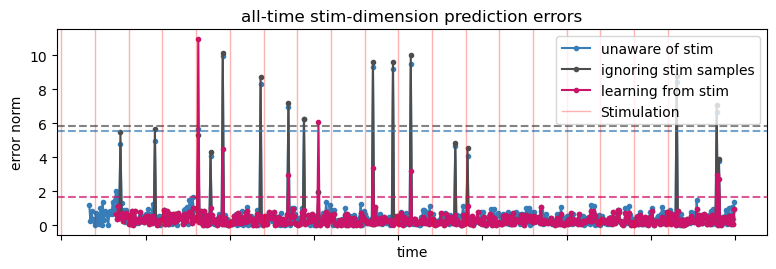

Prediction error plots created successfully!


In [164]:
# Visualize Prediction Errors

print("Creating prediction error plots...")
fig_pred = plot_prediction_errors(srs)
plt.tight_layout()
plt.show()

print("Prediction error plots created successfully!")

## Adaptive vs Base Kernel Regressor Comparison

This section compares two kernel-based approaches for learning the stimulation response:

**🔵 Blue - Base Kernel Regressor**
- Uses fixed length scales (1.0, 1.0, 1.0) across all state space regions
- Treats all regions uniformly regardless of local dynamics

**🟠 Orange - Adaptive Kernel Regressor**  
- Dynamically adjusts kernel bandwidth based on local flow magnitude
- Uses the formula: σ(x) = σ₀ / (1 + γ||V(x)||)
- Provides tighter kernels in regions of fast dynamics and wider kernels in slow regions
- Incorporates knowledge of the underlying dynamical system

The adaptive approach should provide better performance by adapting to the local complexity of the state space.

In [165]:
# Generate Adaptive vs Base Comparison Data

print("Generating adaptive vs base regressor comparison...")
srs_adaptive = make_adaptive_comparison_srs(rng, n_runs=1, show_tqdm=True)

print("Adaptive comparison data generated successfully!")
print(f"Available regressor types: {list(srs_adaptive.keys())}")

# Display basic statistics
for name, regressor_list in srs_adaptive.items():
    sr = regressor_list[0]  # Get first (and only) run
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating adaptive vs base regressor comparison...


Generating adaptive vs base regressor comparison...


Generating adaptive comparison runs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating adaptive vs base regressor comparison...


Generating adaptive comparison runs:   0%|          | 0/1 [00:00<?, ?it/s]

/home/patriciobarber/AdaptiveLatents/adaptive_latents/regressions.py:246: UserWarning: ignoring non-finite input
  warnings.warn("ignoring non-finite input")


Generating adaptive vs base regressor comparison...


Generating adaptive comparison runs:   0%|          | 0/1 [00:00<?, ?it/s]

/home/patriciobarber/AdaptiveLatents/adaptive_latents/regressions.py:246: UserWarning: ignoring non-finite input
  warnings.warn("ignoring non-finite input")


Adaptive comparison data generated successfully!
Available regressor types: ['Base Kernel (learning from stim)', 'Adaptive Kernel (learning from stim)']

Base Kernel (learning from stim):
  - Total prediction errors logged: 564
  - Mean prediction error: nan
  - Std prediction error: nan

Adaptive Kernel (learning from stim):
  - Total prediction errors logged: 564
  - Mean prediction error: nan
  - Std prediction error: nan


In [166]:
def plot_adaptive_prediction_errors(srs_dict, stim_data=None, flip_point=None):
    """
    Plot prediction errors for adaptive vs base regressors.
    
    Parameters:
    -----------
    srs_dict : dict
        Dictionary mapping regressor names to regressor lists or individual regressors
    stim_data : ArrayWithTime, optional
        Stimulation data to mark stimulation events
    flip_point : int, optional
        If provided, adds a vertical black line at this point (for flip experiments)
    """
    print("Creating adaptive vs base prediction error plot...")
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    # Define colors
    colors = {'Base Kernel': '#377eb8ff', 'Adaptive Kernel': '#ff7f0e',
              'Base': '#377eb8ff', 'Adaptive': '#ff7f0e'}
    
    # Plot prediction errors for each regressor
    for name, sr_or_list in srs_dict.items():
        # Handle both list and single regressor formats
        if isinstance(sr_or_list, list):
            sr = sr_or_list[0]  # Get first run
        else:
            sr = sr_or_list
        
        if 'pred_error' in sr.log:
            pred_errors = sr.log['pred_error']
            # Convert to numpy array properly
            pred_errors_array = np.array(pred_errors.data)
            # Extract stim-dimension errors (dimension 2, index 2)
            stim_dim_errors = np.abs(pred_errors_array[:, 2])
            # Create time array
            times = np.arange(len(stim_dim_errors))
            
            # Determine color
            color = colors.get(name, None)
            ax.plot(times, stim_dim_errors, label=name, color=color, linewidth=2, alpha=0.8)
            
            # Add horizontal line for mean error
            mean_error = np.nanmean(stim_dim_errors)
            ax.axhline(mean_error, color=color, linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Add flip point if provided
    if flip_point is not None:
        ax.axvline(x=flip_point, color='black', linestyle='-', 
                  linewidth=2.5, label='Flip Point', alpha=0.9, zorder=10)
    
    # Add stimulation markers if provided
    if stim_data is not None:
        stim_data_array = np.array(stim_data.data)
        actual_stim_indices = np.where(stim_data_array.flatten() != 0)[0]
        
        for i, st in enumerate(actual_stim_indices):
            if i == 0:
                ax.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1, 
                          label='Stimulation Events')
            else:
                ax.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1)
    
    ax.set_xlabel('Time Steps', fontsize=12)
    ax.set_ylabel('Prediction Error (Stim Dimension)', fontsize=12)
    ax.set_title('🔵 Base vs 🟠 Adaptive: Prediction Errors', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    return fig

print("plot_adaptive_prediction_errors function defined!")

plot_adaptive_prediction_errors function defined!


Creating adaptive vs base prediction error plot...
Creating adaptive vs base prediction error plot...


Creating adaptive vs base prediction error plot...
Creating adaptive vs base prediction error plot...


/tmp/ipykernel_94749/2792160499.py:5: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/2792160499.py:5: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


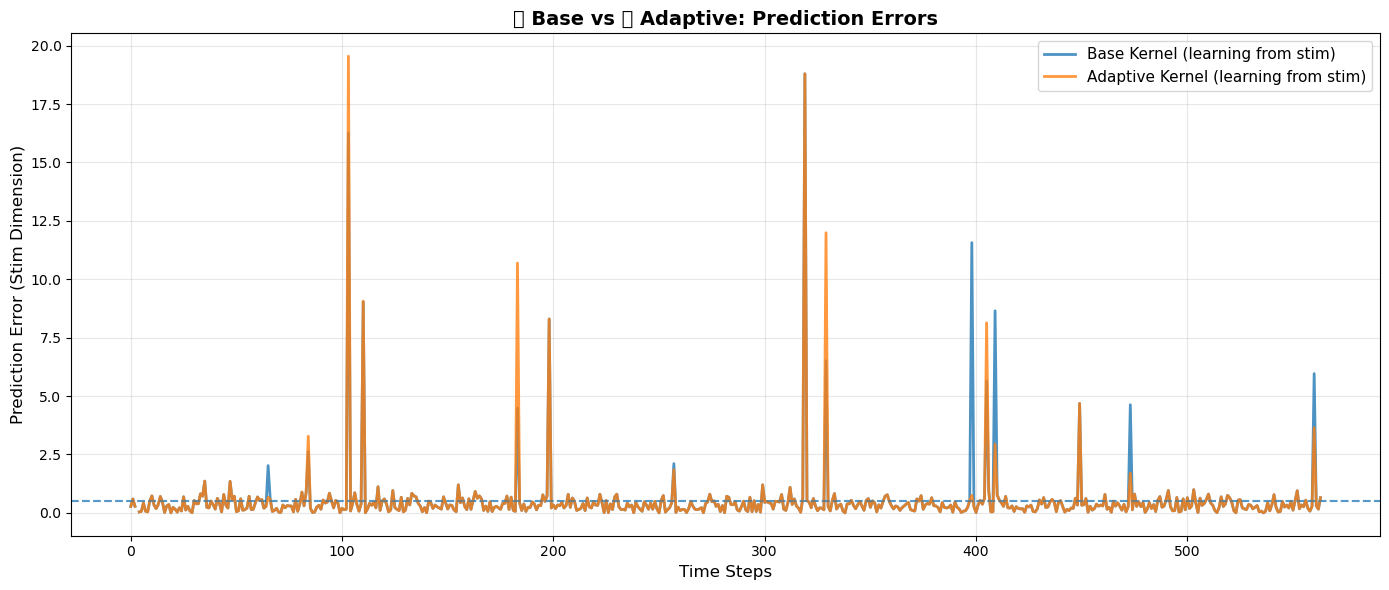

Adaptive vs base prediction error plot created successfully!


In [167]:
# Visualize Adaptive vs Base Prediction Errors

print("Creating adaptive vs base prediction error plot...")
fig_adaptive_pred = plot_adaptive_prediction_errors(srs_adaptive)
plt.tight_layout()
plt.show()

print("Adaptive vs base prediction error plot created successfully!")

## Bandwidth Analysis: Adaptive vs Base Regressor

This section analyzes how the adaptive regressor's bandwidth changes over time compared to the fixed bandwidth of the base regressor. The analysis shows:

- **Bandwidth evolution** over the course of the experiment
- **Relationship between flow magnitude and bandwidth**
- **Response to stimulation events**

The adaptive regressor dynamically adjusts its kernel bandwidth based on local dynamics, while the base regressor maintains constant bandwidth.

In [168]:
# Generate Data with Bandwidth Tracking

print("Generating adaptive regressor with bandwidth tracking...")

# Generate synthetic neural data with stimulation
_, Y_bw, stim_bw = LDS.run_nest_dynamical_system(
    n_rotations, 
    stims_per_rotation=stims_per_rotation, 
    stim_magnitude=stim_magnitude, 
    rng=rng, 
    u_function='curvy', 
    noise=noise_variance
)

# Create flow vector function
flow_func = create_flow_vector_function()

# Create stimulus regressor with bandwidth tracking
sr_adaptive_bw = StimRegressorWithExtraLogging(
    autoreg=StreamingKalmanFilter(), 
    stim_reg=AdaptiveMultiKernelRegressorWithTracking(
        sigma_0=1.0,     # Base bandwidth
        gamma=0.5,       # Flow sensitivity
        flow_vector_func=flow_func,
        maxlen=100
    ), 
    log_level=2, 
    check_dt=True
)

# Run the regressor
sr_adaptive_bw.offline_run_on([(Y_bw, 'X'), (stim_bw, 'stim')], convinient_return=False, show_tqdm=False)
finalize_log(sr_adaptive_bw, stim_bw)

print("Bandwidth tracking data generated successfully!")
print(f"Tracked {len(sr_adaptive_bw.stim_reg.bandwidth_history)} bandwidth values")

Generating adaptive regressor with bandwidth tracking...


Generating adaptive regressor with bandwidth tracking...


Bandwidth tracking data generated successfully!
Tracked 604 bandwidth values


Creating bandwidth analysis plots...
Experiment length: 606 time steps
Bandwidth history length: 604 entries


Creating bandwidth analysis plots...
Experiment length: 606 time steps
Bandwidth history length: 604 entries


/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from fon

Creating bandwidth analysis plots...
Experiment length: 606 time steps
Bandwidth history length: 604 entries


/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/897333765.py:96: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from fon

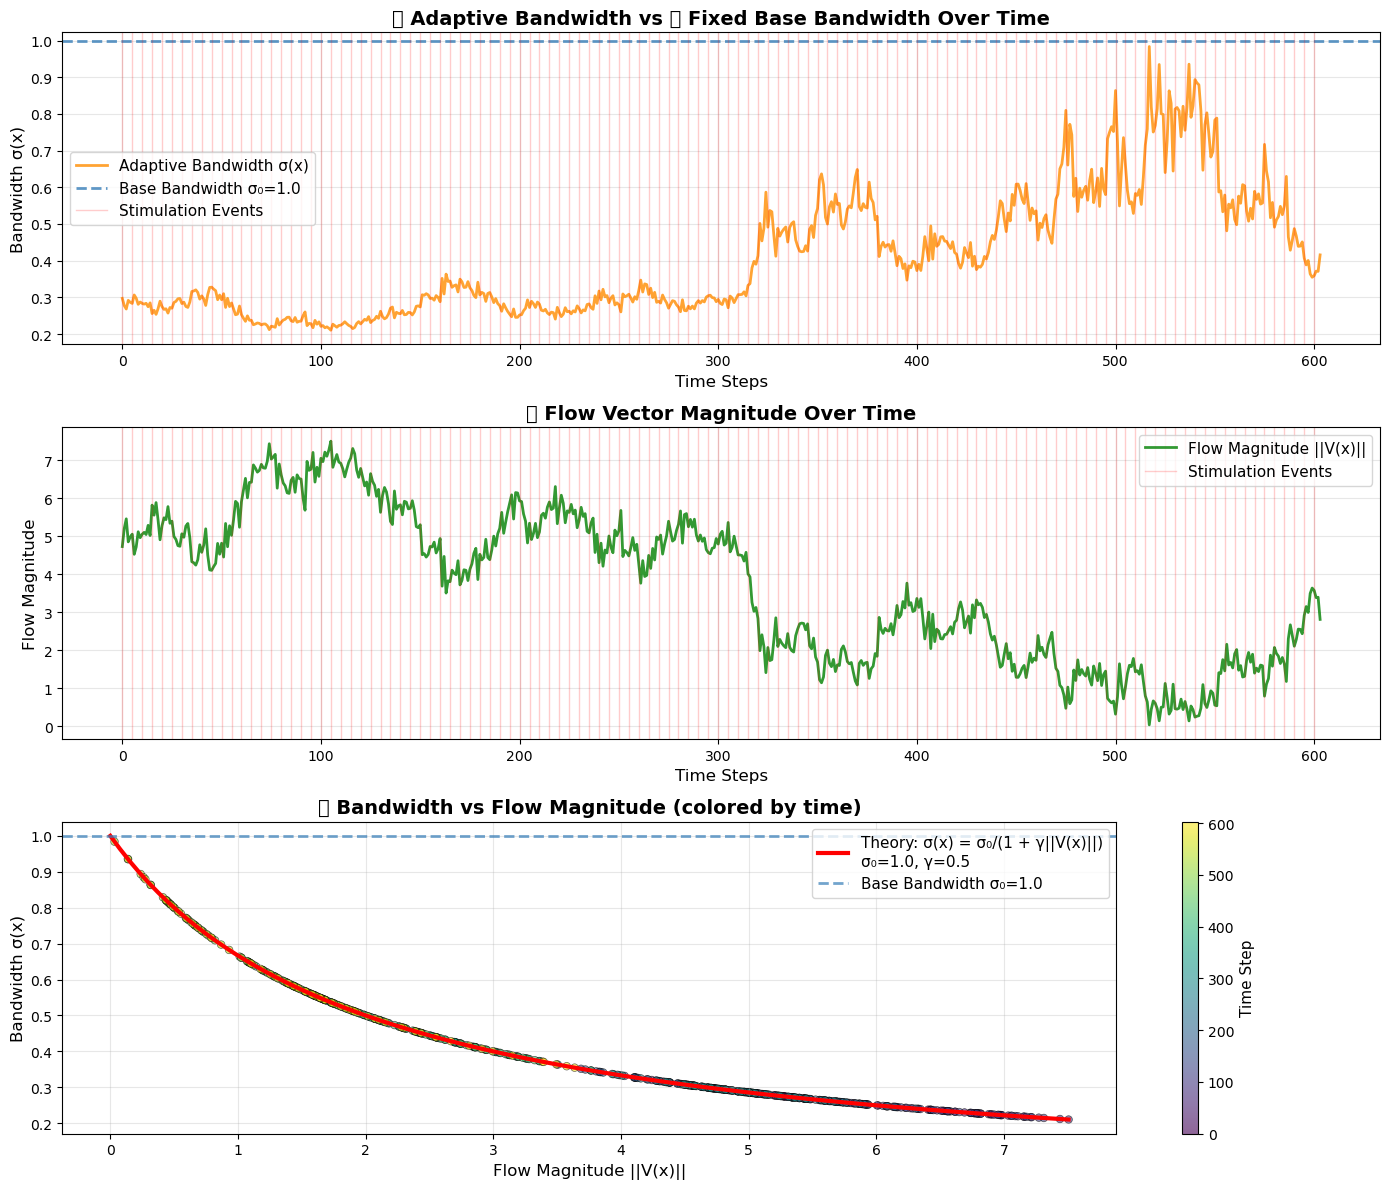


 Bandwidth Analysis Summary:
   Base bandwidth σ₀: 1.000
   Flow sensitivity γ: 0.500
   Number of stimulation events: 604

Bandwidth analysis visualization completed successfully!


In [169]:
# Visualize Bandwidth Analysis

print("Creating bandwidth analysis plots...")

# Extract bandwidth and flow data
bandwidth_history = np.array(sr_adaptive_bw.stim_reg.bandwidth_history)
flow_magnitude_history = np.array(sr_adaptive_bw.stim_reg.flow_magnitude_history)

# Get the actual experiment length from the data
n_experiment_steps = len(stim_bw)
print(f"Experiment length: {n_experiment_steps} time steps")
print(f"Bandwidth history length: {len(bandwidth_history)} entries")

# Trim bandwidth history to match experiment length if needed
if len(bandwidth_history) > n_experiment_steps:
    print(f"Trimming bandwidth history from {len(bandwidth_history)} to {n_experiment_steps} to match experiment")
    bandwidth_history = bandwidth_history[:n_experiment_steps]
    flow_magnitude_history = flow_magnitude_history[:n_experiment_steps]

time_steps = np.arange(len(bandwidth_history))

# Extract stimulation times
stim_times = []
for i, s in enumerate(stim_bw):
    if i >= len(bandwidth_history):  # Only include stim times within bandwidth tracking range
        break
    if hasattr(s, 'data'):
        stim_data = s.data
    else:
        stim_data = s
    if np.any(stim_data != 0):
        stim_times.append(i)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Bandwidth over time
ax1.plot(time_steps, bandwidth_history, 'darkorange', linewidth=2, label='Adaptive Bandwidth σ(x)', alpha=0.8)
ax1.axhline(y=sr_adaptive_bw.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Base Bandwidth σ₀={sr_adaptive_bw.stim_reg.sigma_0}')

# Add stimulation event markers (every 5th to avoid clutter)
if stim_times:
    for i, st in enumerate(stim_times[::5]):
        if i == 0:
            ax1.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1, label='Stimulation Events')
        else:
            ax1.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1)

ax1.set_xlabel('Time Steps', fontsize=12)
ax1.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax1.set_title('🟠 Adaptive Bandwidth vs 🔵 Fixed Base Bandwidth Over Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Flow magnitude over time
ax2.plot(time_steps, flow_magnitude_history, 'green', linewidth=2, label='Flow Magnitude ||V(x)||', alpha=0.8)

if stim_times:
    for i, st in enumerate(stim_times[::5]):
        if i == 0:
            ax2.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1, label='Stimulation Events')
        else:
            ax2.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1)

ax2.set_xlabel('Time Steps', fontsize=12)
ax2.set_ylabel('Flow Magnitude', fontsize=12)
ax2.set_title('🟢 Flow Vector Magnitude Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Bandwidth vs Flow Magnitude scatter
scatter = ax3.scatter(flow_magnitude_history, bandwidth_history, alpha=0.6, s=30, 
                     c=time_steps, cmap='viridis', edgecolors='black', linewidth=0.5)

# Show theoretical relationship
flow_range = np.linspace(0, np.max(flow_magnitude_history), 100)
theoretical_bandwidth = sr_adaptive_bw.stim_reg.sigma_0 / (1 + sr_adaptive_bw.stim_reg.gamma * flow_range)
ax3.plot(flow_range, theoretical_bandwidth, 'r-', linewidth=3, 
         label=f'Theory: σ(x) = σ₀/(1 + γ||V(x)||)\nσ₀={sr_adaptive_bw.stim_reg.sigma_0}, γ={sr_adaptive_bw.stim_reg.gamma}')

# Add base bandwidth reference line
ax3.axhline(y=sr_adaptive_bw.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Base Bandwidth σ₀={sr_adaptive_bw.stim_reg.sigma_0}')

ax3.set_xlabel('Flow Magnitude ||V(x)||', fontsize=12)
ax3.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax3.set_title('🟡 Bandwidth vs Flow Magnitude (colored by time)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11, loc='upper right')
ax3.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Time Step', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n Bandwidth Analysis Summary:")
print(f"   Base bandwidth σ₀: {sr_adaptive_bw.stim_reg.sigma_0:.3f}")
print(f"   Flow sensitivity γ: {sr_adaptive_bw.stim_reg.gamma:.3f}")

print(f"   Number of stimulation events: {len(stim_times)}")

print("\nBandwidth analysis visualization completed successfully!")

## 3D Surface Plot: Ground Truth vs Learned Manifolds

This section visualizes the learned stimulation response manifolds for both Base and Adaptive kernel regressors, comparing them against the ground truth surface.

**Key aspects:**
- Gray surface: Ground truth stimulus effect S(x) = [0, 0, stim_magnitude * x₀/||x₀,x₁||]
- Colored scatter points: Learned responses at training locations
- Point colors indicate prediction error magnitude

In [170]:
# Create 3D Surface Plots for Base and Adaptive Regressors

import itertools

def create_surface_comparison_plots(srs_dict, stim_magnitude=10):
    """
    Create 3D surface plots comparing learned manifolds to ground truth.
    
    Parameters:
    -----------
    srs_dict : dict
        Dictionary with 'Base Kernel' and 'Adaptive Kernel' regressors
    stim_magnitude : float
        Magnitude of stimulation for ground truth calculation
    """
    
    def true_S(state):
        """Ground truth stimulus response function."""
        u = np.zeros(3)
        u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])
        return u
    
    # Create figure with two 3D subplots
    fig = plt.figure(figsize=(18, 8))
    
    # Define extent and resolution for ground truth surface
    # Increased depth from 14 to 25 for more surface detail
    extent = 20
    depth = 25
    X, Y = np.meshgrid(np.linspace(-extent, extent, depth), 
                       np.linspace(-extent, extent, depth))
    Z = np.zeros_like(X)
    
    # Calculate ground truth surface
    for i_x, i_y in itertools.product(range(depth), range(depth)):
        Z[i_x, i_y] = true_S([X[i_x, i_y], Y[i_x, i_y], None])[2]
    
    # Plot for each regressor type
    for idx, (name, sr_or_list) in enumerate(srs_dict.items()):
        # Handle both list and single regressor formats
        if isinstance(sr_or_list, list):
            sr = sr_or_list[0]
        else:
            sr = sr_or_list
        
        # Create subplot
        ax = fig.add_subplot(1, 2, idx+1, projection='3d', computed_zorder=False)
        
        # Plot ground truth surface
        ax.plot_surface(X, Y, Z, color='#C9C9C9', alpha=0.5, label='Ground Truth')
        
        # Get learned history - try different attributes
        h = None
        if hasattr(sr.stim_reg, 'history'):
            h = sr.stim_reg.history
        elif hasattr(sr.stim_reg, 'input_histories') and sr.stim_reg.input_histories is not None:
            # Build history from input_histories and output_history
            # input_histories is a list of arrays, output_history is an array
            if len(sr.stim_reg.input_histories) > 0 and sr.stim_reg.output_history is not None:
                # Concatenate input histories and output history
                input_concat = np.concatenate([np.array(ih) for ih in sr.stim_reg.input_histories], axis=1)
                output_hist = np.array(sr.stim_reg.output_history)
                h = np.concatenate([input_concat, output_hist], axis=1)
        
        if h is not None:
            h = h[~np.isnan(h).any(axis=1)]
            
            if len(h) > 0:
                # Calculate errors for coloring
                errors = [np.linalg.norm(true_S(row[:3]) - row[-3:]) for row in h]
                
                # Plot learned points - increased size from 30 to 50
                scatter = ax.scatter(h[:, 0], h[:, 1], h[:, -1], 
                                   c=errors, 
                                   zorder=100, 
                                   alpha=0.9, 
                                   cmap='plasma', 
                                   vmin=0,
                                   s=50,
                                   edgecolors='black',
                                   linewidth=0.7)
                
                # Add colorbar
                cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=10)
                cbar.set_label('Prediction Error', fontsize=10)
        
        # Set labels and title
        ax.set_xlabel('Neural State x₀', fontsize=11)
        ax.set_ylabel('Neural State x₁', fontsize=11)
        ax.set_zlabel('Learned Stim Response', fontsize=11)
        
        title_name = name.replace(' (learning from stim)', '').replace(' Kernel', '')
        ax.set_title(f'{title_name} Regressor:\nLearned vs Ground Truth Manifold', 
                    fontsize=12, fontweight='bold')
        
        # Set view and limits
        ax.view_init(elev=24, azim=147, roll=0)
        ax.set_xlim(-15*3/2, 15*3/2)
        ax.set_ylim(-15*3/2, 15*3/2)
        ax.set_zlim(-15, 15)
        
        # Clean up appearance
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.xaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
        ax.yaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
        ax.zaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    
    plt.tight_layout()
    return fig

print("Surface comparison plotting function defined!")
print("✓ Increased surface resolution from 14x14 to 25x25 points")
print("✓ Increased scatter point size from 30 to 50 for better visibility")

Surface comparison plotting function defined!
✓ Increased surface resolution from 14x14 to 25x25 points
✓ Increased scatter point size from 30 to 50 for better visibility


Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold



Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


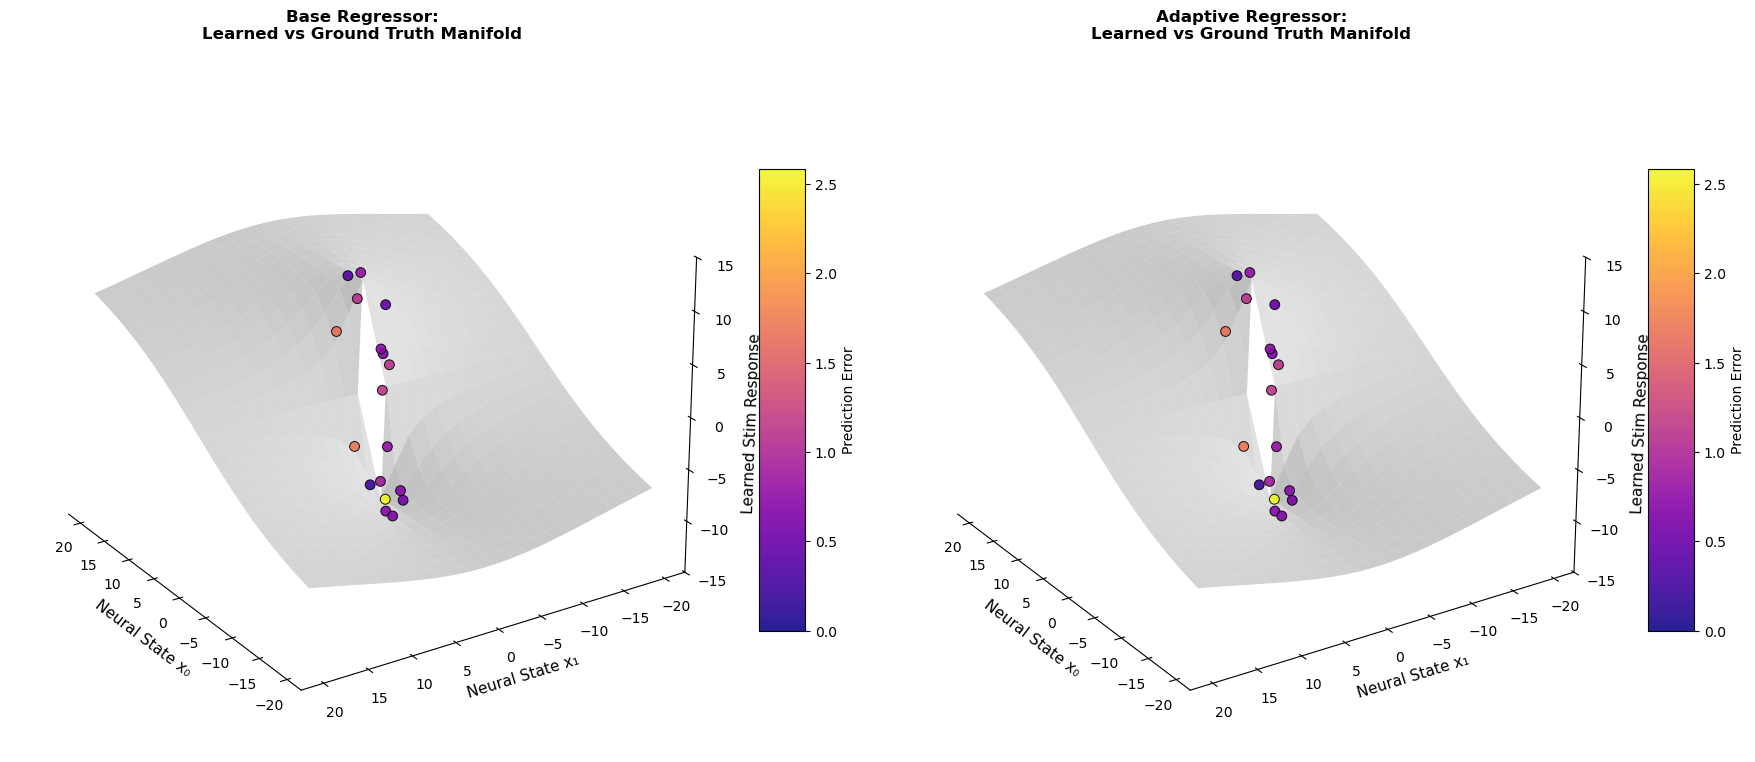


📊 Surface Plot Interpretation:
   - Gray surface: Ground truth stimulus effect
   - Colored points: Learned responses at training locations
   - Color indicates prediction error (plasma colormap)
   - Darker (purple) = lower error, Brighter (yellow) = higher error

Surface plots created successfully!


In [171]:
# Generate and Display Surface Plots for Regular Stimulation Experiment

print("Creating 3D surface plots comparing Base vs Adaptive kernel regressors...")
print("This shows how each method learns the stimulation response manifold\n")

fig_surfaces = create_surface_comparison_plots(srs_adaptive, stim_magnitude=stim_magnitude)
plt.show()

print("\n📊 Surface Plot Interpretation:")
print("   - Gray surface: Ground truth stimulus effect")
print("   - Colored points: Learned responses at training locations")
print("   - Color indicates prediction error (plasma colormap)")
print("   - Darker (purple) = lower error, Brighter (yellow) = higher error")
print("\nSurface plots created successfully!")


Creating surface plots for Random Stimulation experiment...



Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])



Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


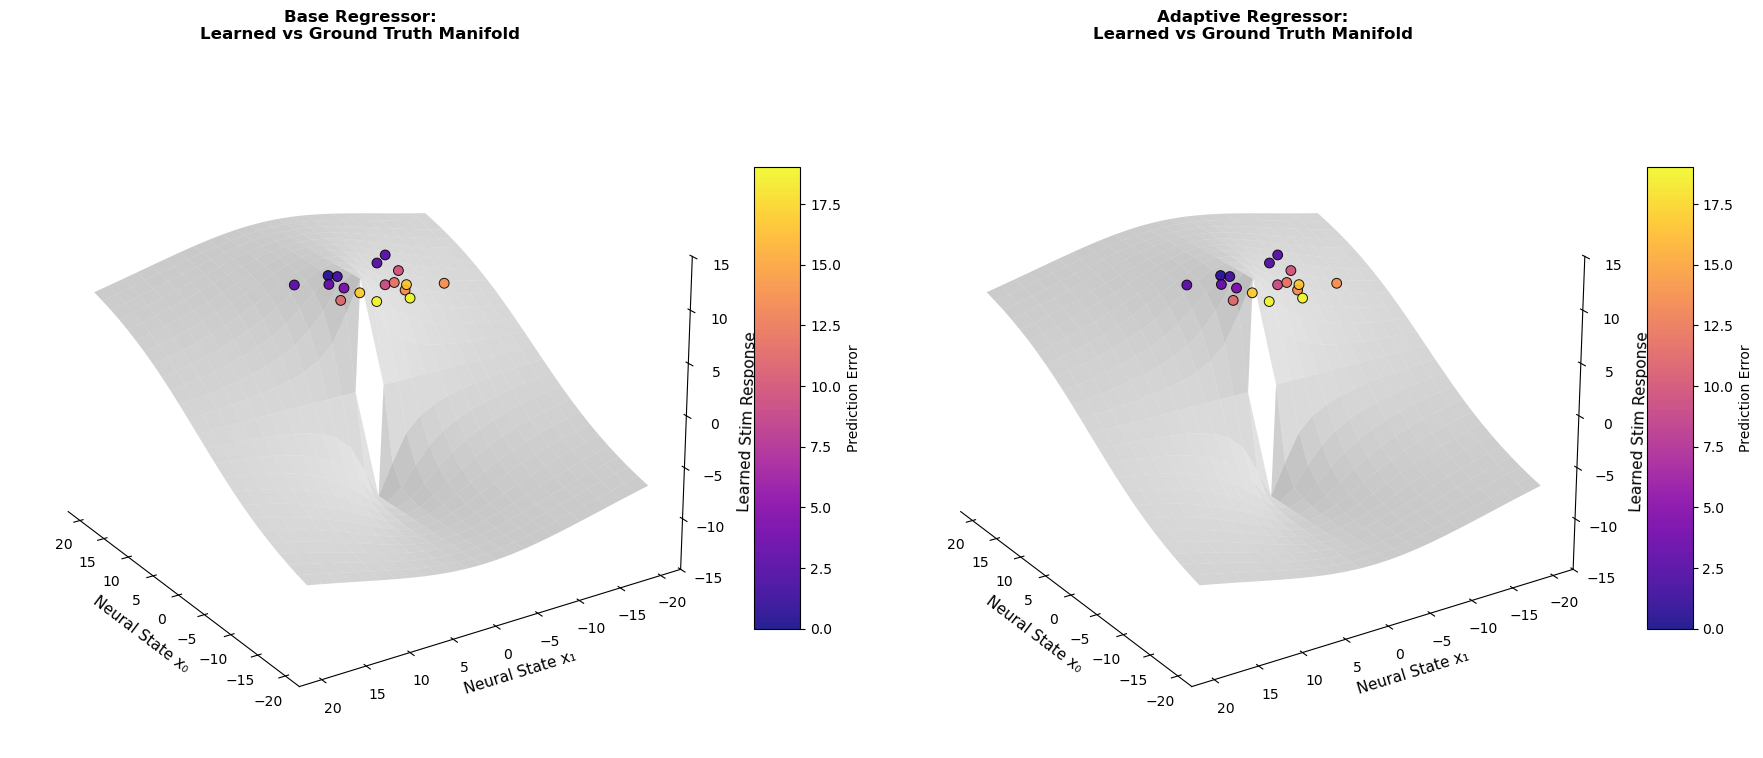


Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


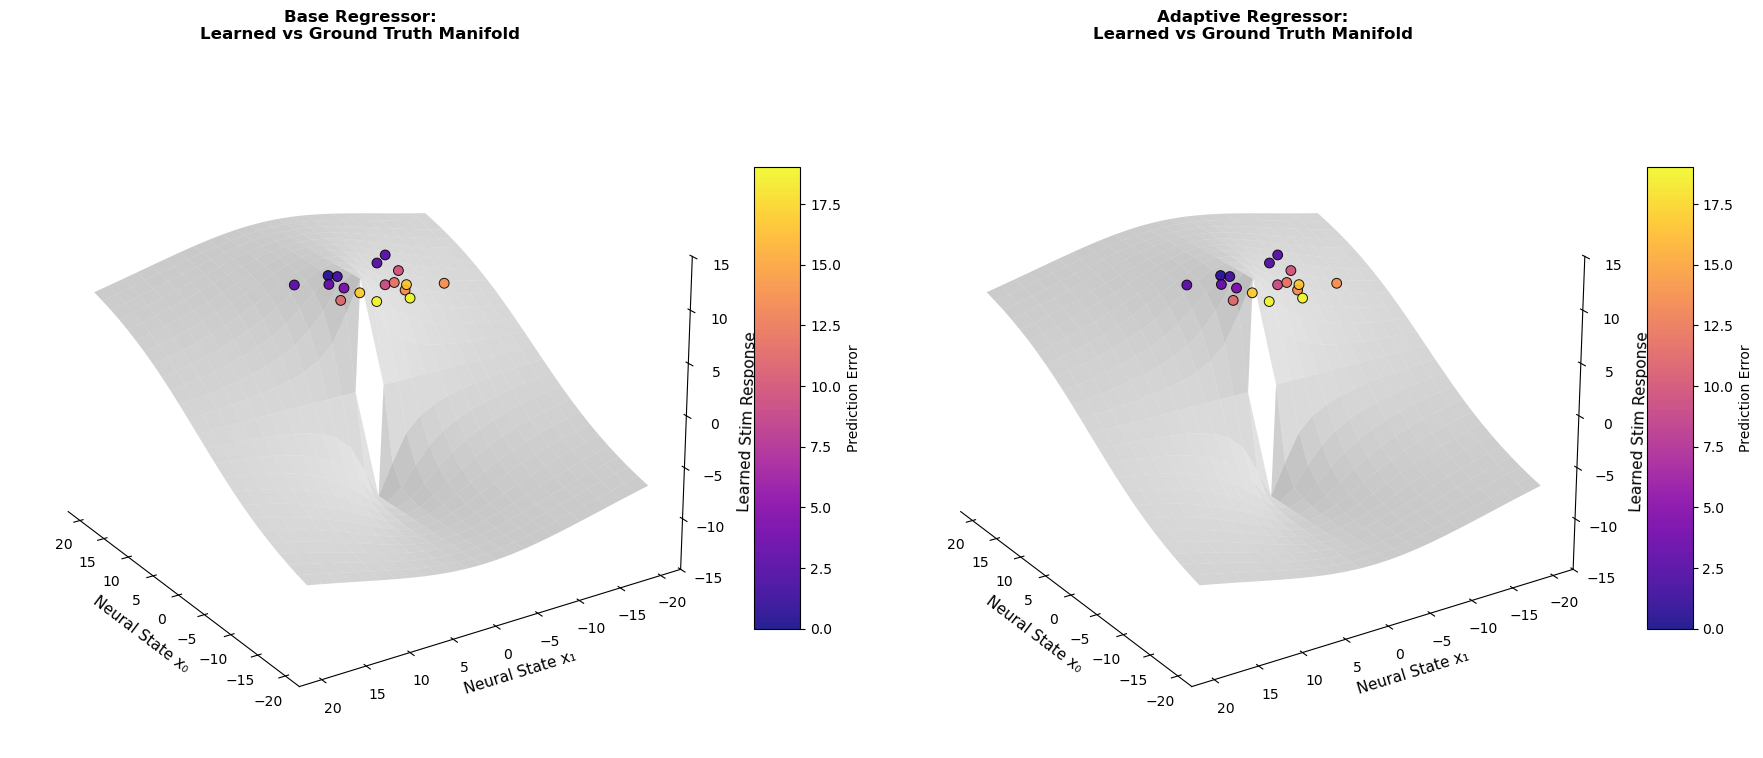


Creating surface plots for Burst Stimulation experiment...



Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


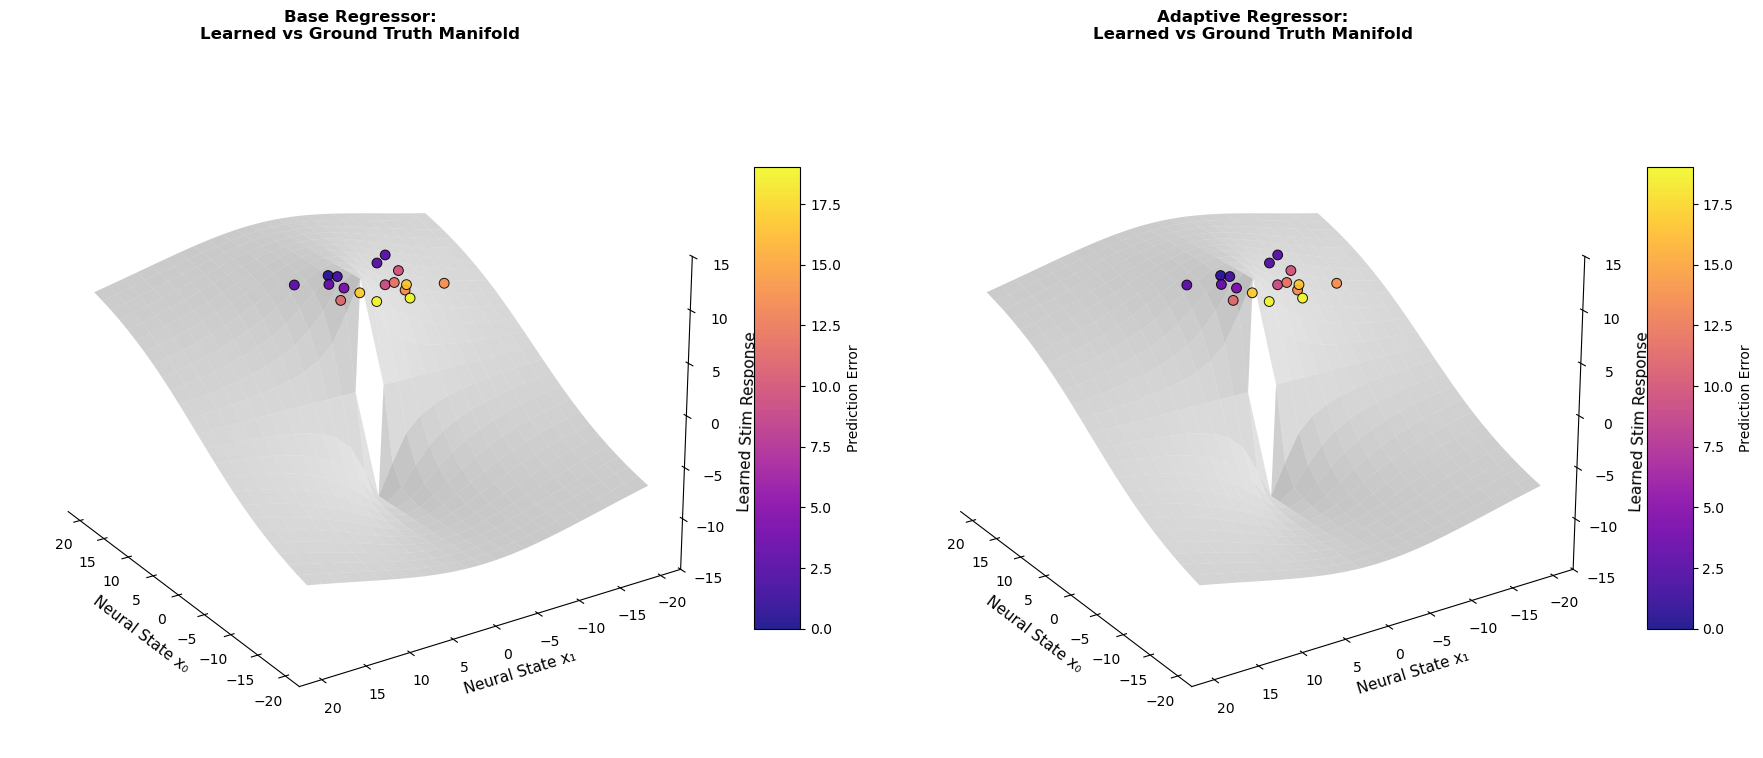


Creating surface plots for Burst Stimulation experiment...


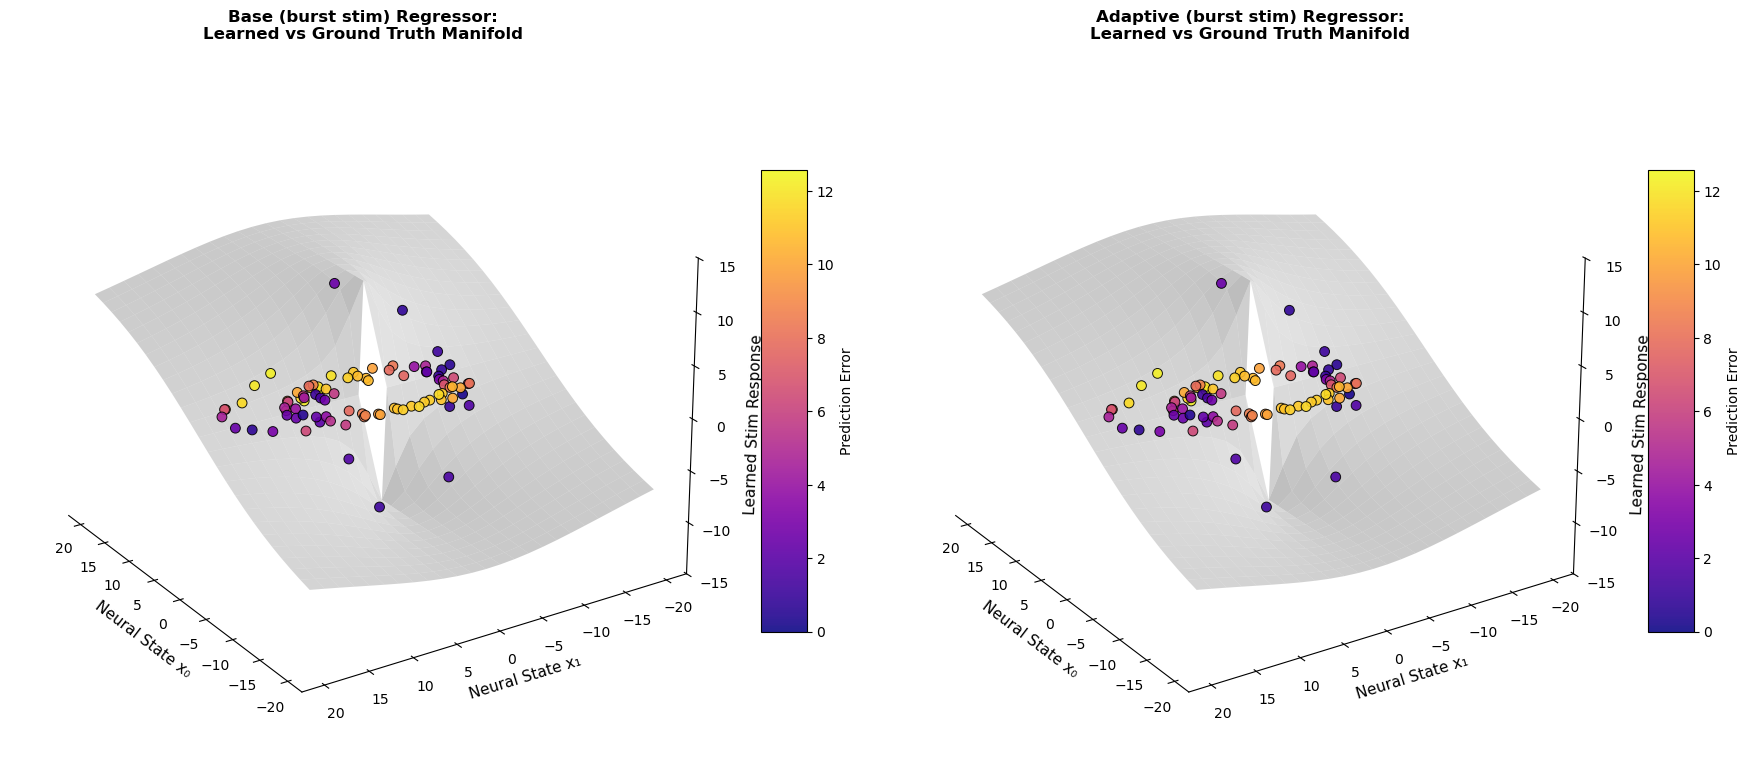


Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


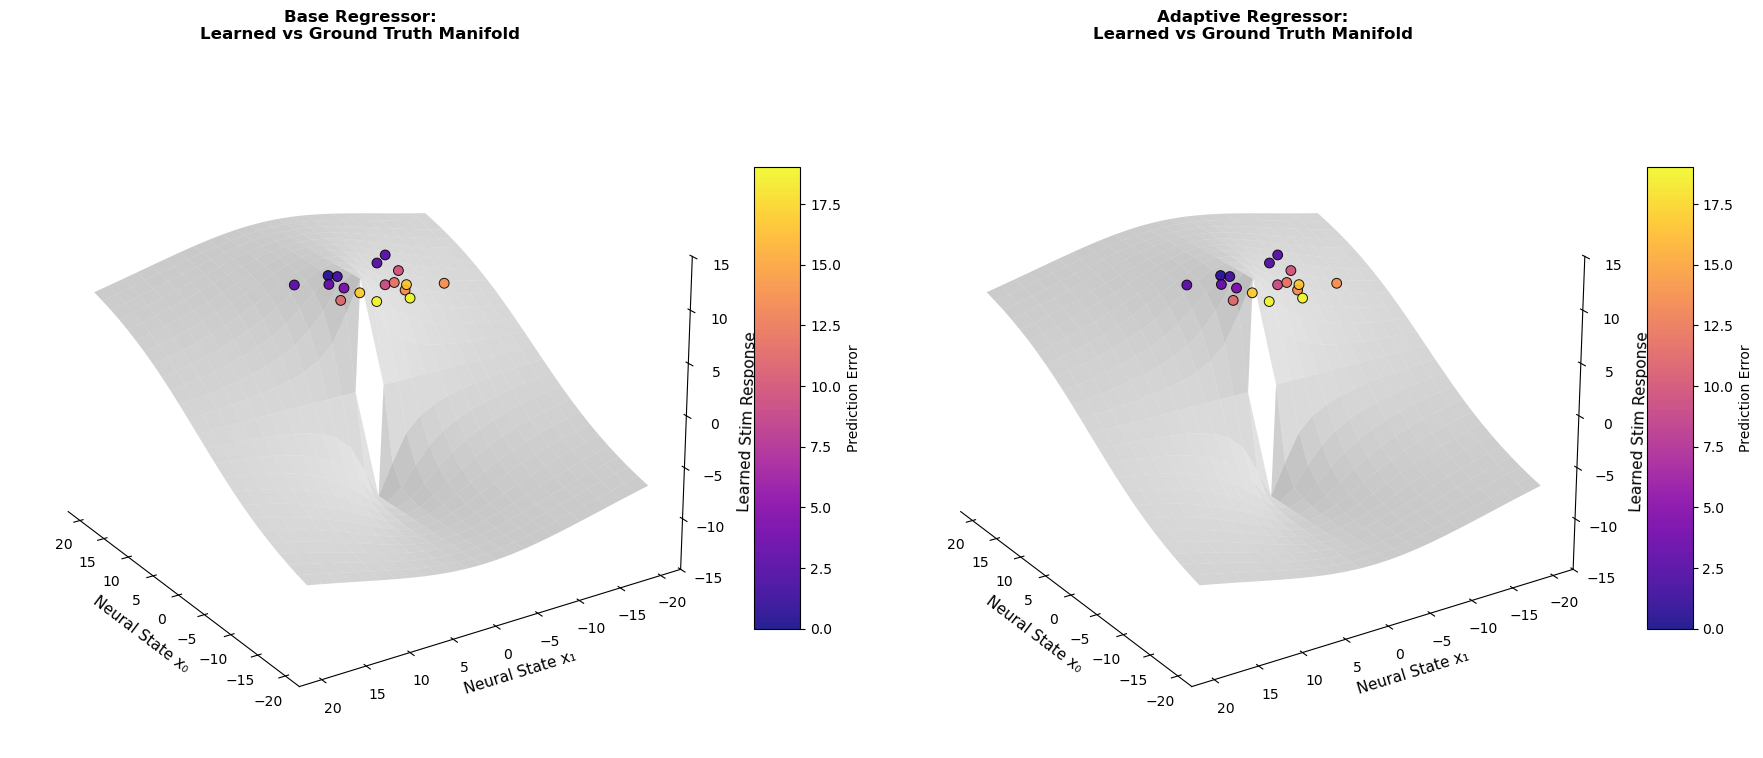


Creating surface plots for Burst Stimulation experiment...


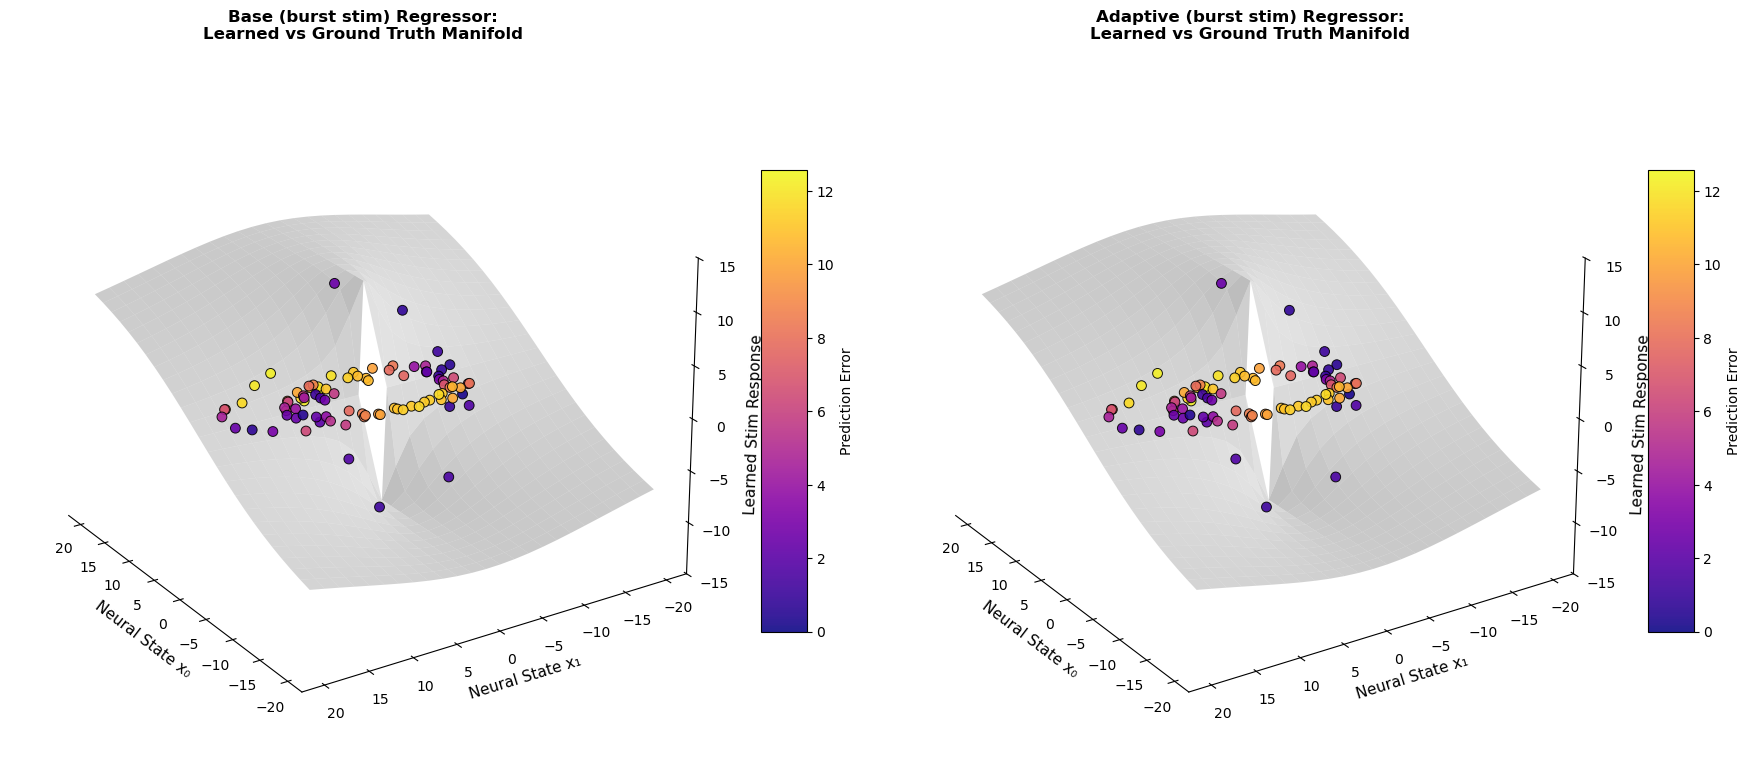


Creating surface plots for Curvy Flips experiment...



Creating surface plots for Random Stimulation experiment...


/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


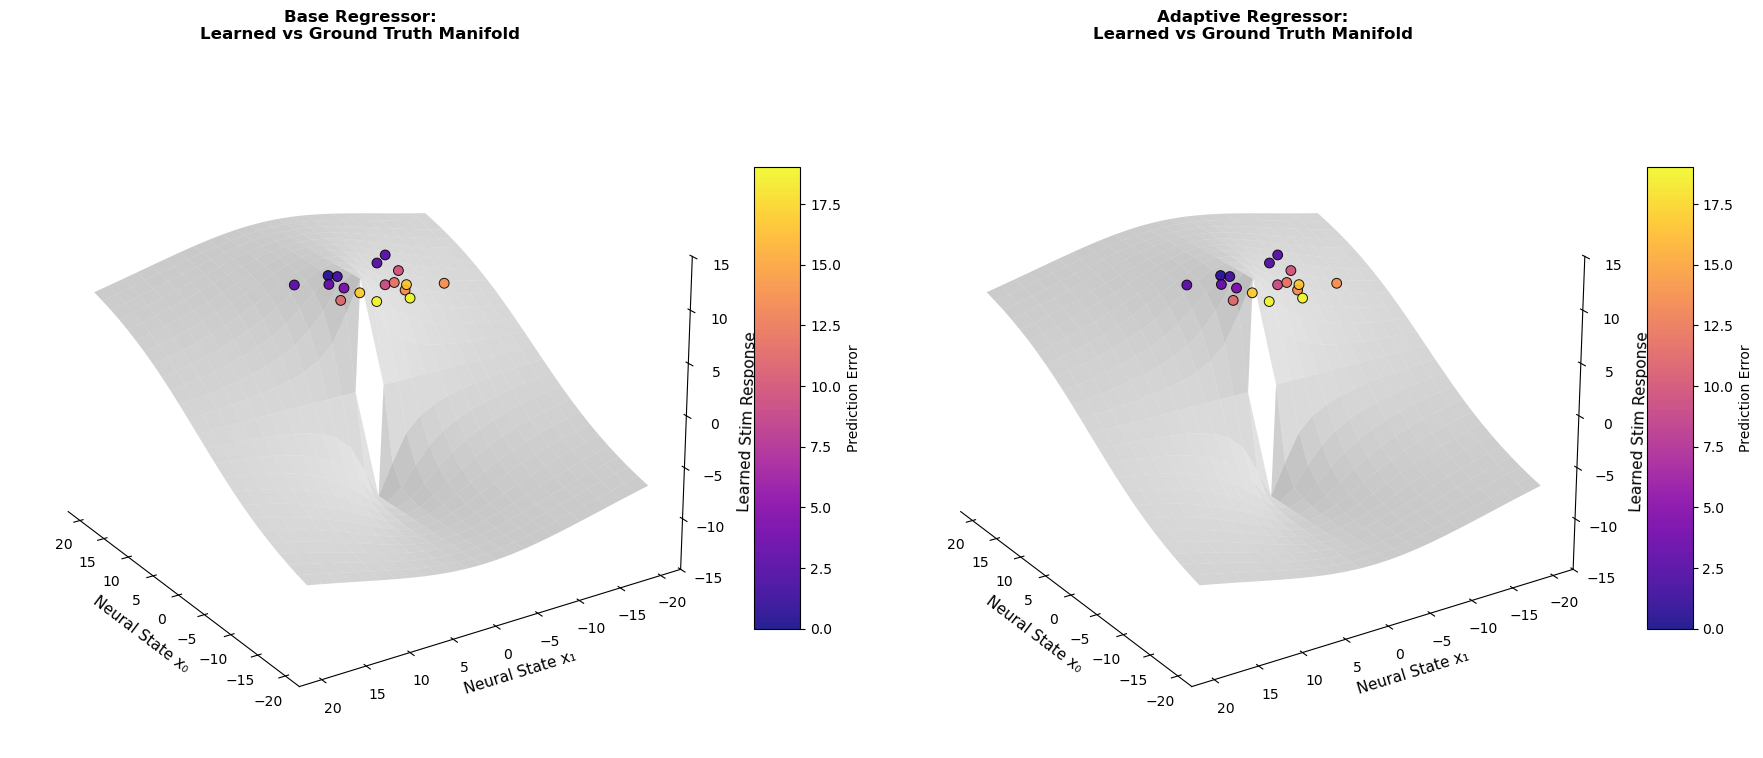


Creating surface plots for Burst Stimulation experiment...


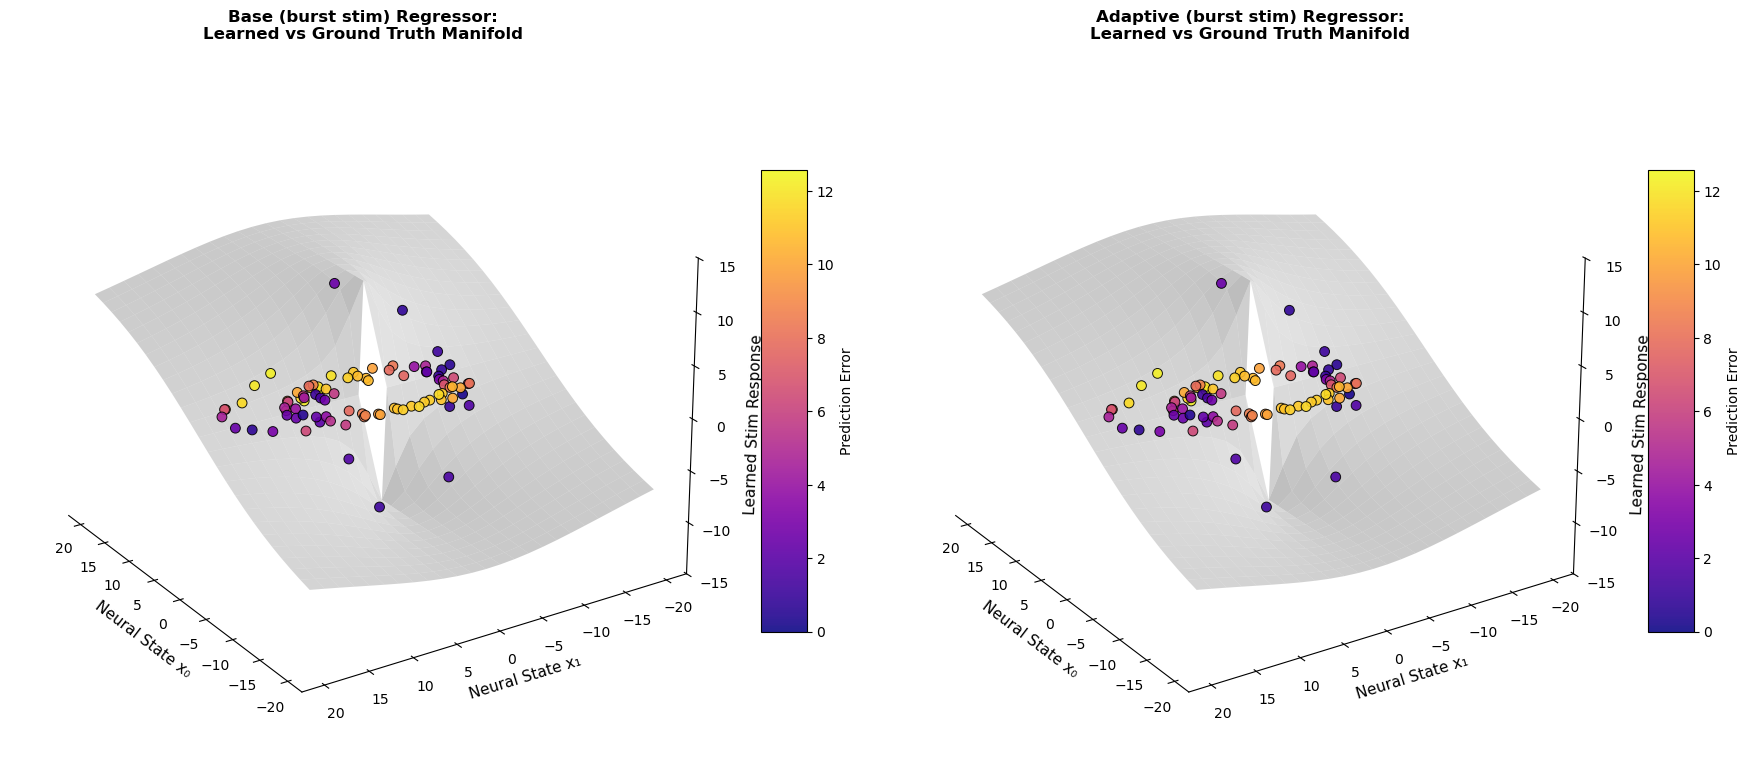


Creating surface plots for Curvy Flips experiment...


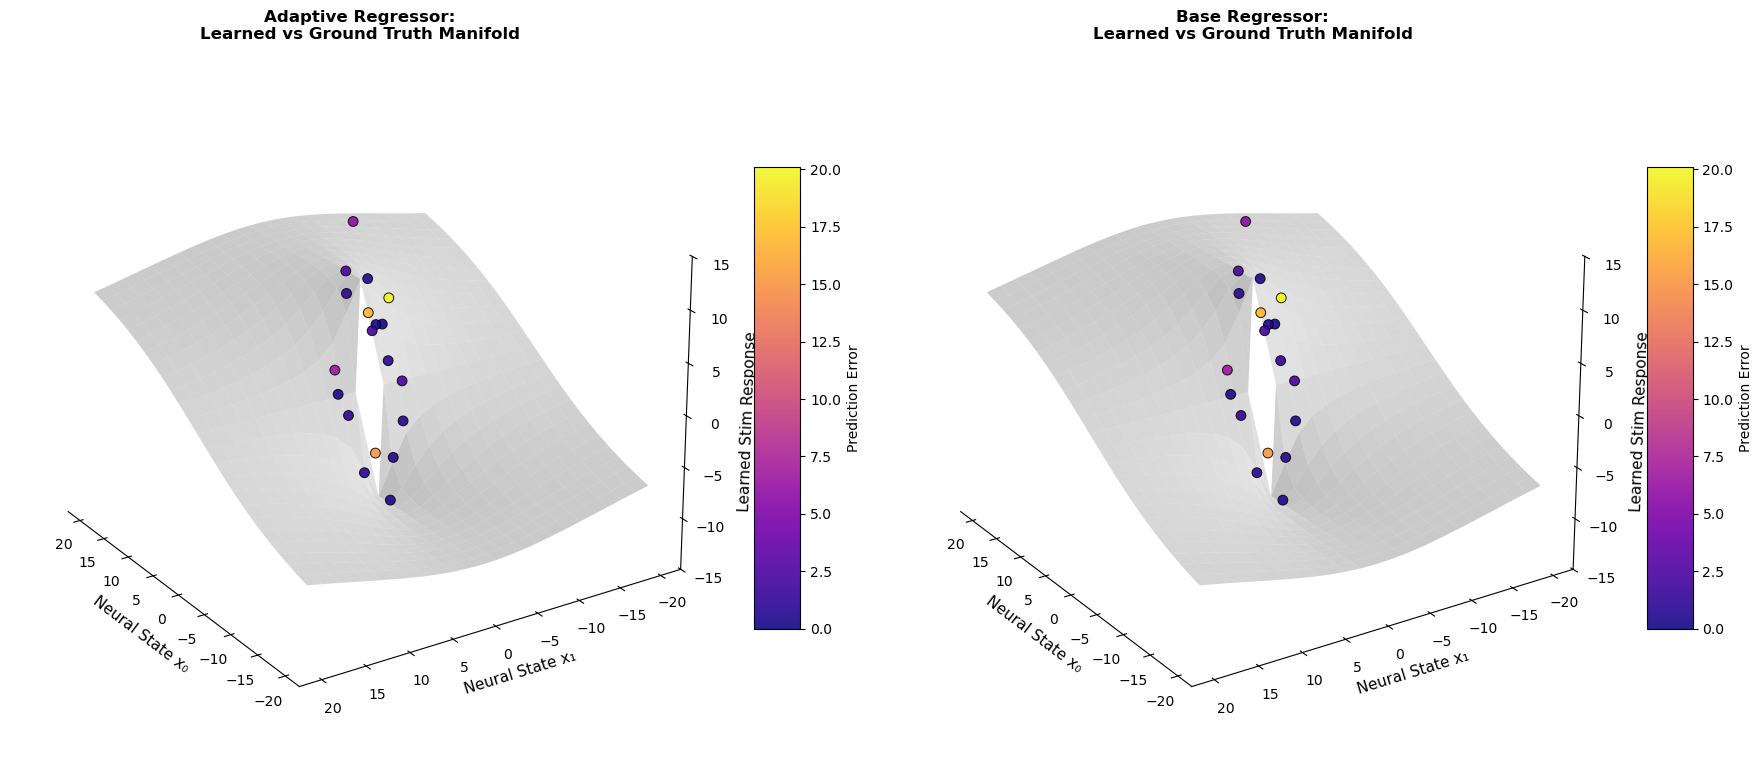


All surface plot visualizations completed!


In [172]:
# Optional: Create Surface Plots for Other Experiments

# For Random Stimulation
if 'srs_adaptive_random' in globals():
    print("\nCreating surface plots for Random Stimulation experiment...")
    fig_surfaces_random = create_surface_comparison_plots(srs_adaptive_random, stim_magnitude=stim_magnitude)
    plt.show()

# For Burst Stimulation  
if 'srs_burst_adaptive' in globals():
    print("\nCreating surface plots for Burst Stimulation experiment...")
    fig_surfaces_burst = create_surface_comparison_plots(srs_burst_adaptive, stim_magnitude=stim_magnitude)
    plt.show()

# For Curvy Flips
if 'srs_curvy_flips' in globals():
    print("\nCreating surface plots for Curvy Flips experiment...")
    fig_surfaces_flips = create_surface_comparison_plots(srs_curvy_flips, stim_magnitude=stim_magnitude)
    plt.show()

print("\nAll surface plot visualizations completed!")

## Random Stimulation Experiment

This section runs the same analysis but with **random stimulation** instead of state-dependent curvy stimulation.

**Key Difference:**
- **Curvy stimulation**: Stimuli depend on neural state (proportional to x₀/||x₀,x₁||)
- **Random stimulation**: Stimuli are constant magnitude, randomly placed in time

In [173]:
# Functions for Random Stimulation Experiment

def single_make_srs_random(rng):
    """Create a single set of stimulus regressors with RANDOM stimulation."""
    # Use FEWER stims per rotation to ensure sparse, random placement
    random_stims_per_rotation = 1  # Keep at 1 for comparable number of stims
    
    # Generate synthetic neural data with RANDOM stimulation (constant magnitude)
    _, Y, stim = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=random_stims_per_rotation, 
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='constant',  # Random constant stimulation instead of curvy
        noise=noise_variance
    )

    # Create three different stimulus regressors
    sr1 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True
    )  # Learning from stim
    
    sr2 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True, 
        attempt_correction=False
    )  # Ignoring stim samples
    
    sr3 = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(), 
        log_level=2, 
        check_dt=True, 
        attempt_correction=False, 
        heed_stimuli=False
    )  # Unaware of stim

    # Set zero prior for manifold comparison
    sr3.stim_reg.observe(np.zeros(4), np.zeros(3))
    
    # Create error evaluation function
    s_hat_error_function = make_s_hat_error_function(rng)
    sr1.s_hat_error_function = s_hat_error_function
    sr3.s_hat_error_function = s_hat_error_function

    # Run the regressors on the data
    pre_srs = {
        'learning from stim': sr1, 
        'ignoring stim samples': sr2, 
        'unaware of stim': sr3
    }
    
    for sr in pre_srs.values():
        sr.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
        finalize_log(sr, stim)

    return pre_srs

def make_srs_random(rng, n_runs=1, show_tqdm=False):
    """Create multiple runs of stimulus regressors with RANDOM stimulation."""
    srs = []
    for _ in tqdm.trange(n_runs, disable=not show_tqdm, desc="Generating random stim regressor runs"):
        srs.append(single_make_srs_random(rng))
        assert set(srs[-1].keys()) == set(standard_kinds_of_sr)

    # Reorganize data by regressor type
    srs = {k: [run[k] for run in srs] for k in srs[0].keys()}
    return srs

print("Random stimulation experiment functions defined successfully!")

Random stimulation experiment functions defined successfully!


In [174]:
# Generate Random Stimulation Data

print("Generating stimulus regressor models with RANDOM stimulation...")
srs_random = make_srs_random(rng, n_runs=1, show_tqdm=True)

print("Models generated successfully!")
print(f"Available regressor types: {list(srs_random.keys())}")

# Display basic statistics
for name, regressor_list in srs_random.items():
    sr = regressor_list[0]  # Get first (and only) run
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating stimulus regressor models with RANDOM stimulation...


Generating stimulus regressor models with RANDOM stimulation...


Generating random stim regressor runs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating stimulus regressor models with RANDOM stimulation...


Generating random stim regressor runs:   0%|          | 0/1 [00:00<?, ?it/s]

Models generated successfully!
Available regressor types: ['learning from stim', 'ignoring stim samples', 'unaware of stim']

learning from stim:
  - Total prediction errors logged: 559
  - Mean prediction error: nan
  - Std prediction error: nan

ignoring stim samples:
  - Total prediction errors logged: 559
  - Mean prediction error: 0.9507
  - Std prediction error: 1.6400

unaware of stim:
  - Total prediction errors logged: 581
  - Mean prediction error: 0.9886
  - Std prediction error: 1.5870


In [175]:
# Generate Adaptive vs Base Comparison for Random Stimulation

def create_adaptive_comparison_srs_random(rng):
    """Create stimulus regressors comparing base and adaptive kernel methods with RANDOM stim."""
    # Generate synthetic neural data with RANDOM stimulation
    _, Y, stim = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=stims_per_rotation, 
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='constant',  # Random constant stimulation
        noise=noise_variance
    )

    # Create flow vector function
    flow_func = create_flow_vector_function()

    # Create stimulus regressor with base multi-kernel regressor
    sr_base = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(length_scales=(1.0, 1.0, 1.0), maxlen=100), 
        log_level=2, 
        check_dt=True
    )
    
    # Create stimulus regressor with adaptive multi-kernel regressor
    sr_adaptive = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=AdaptiveMultiKernelRegressor(
            sigma_0=1.0,     # Base bandwidth
            gamma=0.5,       # Flow sensitivity
            flow_vector_func=flow_func,
            maxlen=100
        ), 
        log_level=2, 
        check_dt=True
    )

    # Run both regressors on the same data
    pre_srs = {
        'Base Kernel': sr_base, 
        'Adaptive Kernel': sr_adaptive
    }
    
    for sr in pre_srs.values():
        sr.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
        finalize_log(sr, stim)

    return pre_srs, stim

print("Generating adaptive vs base comparison with RANDOM stimulation...")
srs_adaptive_random, stim_adaptive_random = create_adaptive_comparison_srs_random(rng)

print("Adaptive vs base comparison generated successfully!")
print(f"Available regressor types: {list(srs_adaptive_random.keys())}")

# Display basic statistics
for name, sr in srs_adaptive_random.items():
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating adaptive vs base comparison with RANDOM stimulation...


Generating adaptive vs base comparison with RANDOM stimulation...


Adaptive vs base comparison generated successfully!
Available regressor types: ['Base Kernel', 'Adaptive Kernel']

Base Kernel:
  - Total prediction errors logged: 563
  - Mean prediction error: nan
  - Std prediction error: nan

Adaptive Kernel:
  - Total prediction errors logged: 563
  - Mean prediction error: nan
  - Std prediction error: nan


Creating adaptive vs base prediction error plots for RANDOM stimulation...
Found 19 actual stimulation events
Stim times: [ 12  17 130 141 160 163 178 225 232 274 308 322 334 438 448 460 552 558
 575]...


Creating adaptive vs base prediction error plots for RANDOM stimulation...
Found 19 actual stimulation events
Stim times: [ 12  17 130 141 160 163 178 225 232 274 308 322 334 438 448 460 552 558
 575]...


/tmp/ipykernel_94749/2471521247.py:45: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/2471521247.py:45: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


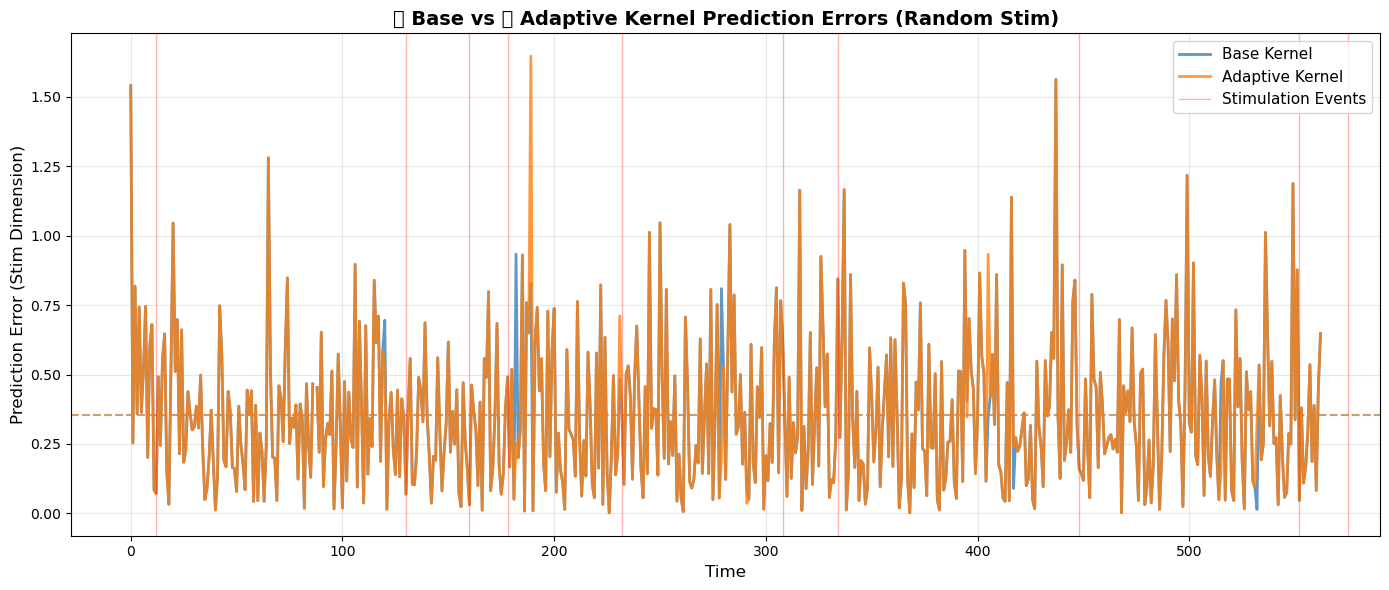

Adaptive vs base prediction error plot created successfully!


In [176]:
# Visualize Adaptive vs Base Prediction Errors for Random Stimulation

print("Creating adaptive vs base prediction error plots for RANDOM stimulation...")

# Get actual stim times from the raw stim data
stim_data_array_for_plot = np.array(stim_adaptive_random.data)
actual_stim_indices = np.where(stim_data_array_for_plot.flatten() != 0)[0]

print(f"Found {len(actual_stim_indices)} actual stimulation events")
print(f"Stim times: {actual_stim_indices[:20]}...")

# Create figure manually with proper stim markers
fig_adaptive_random, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot prediction errors for both regressors
colors = {'Base Kernel': '#377eb8ff', 'Adaptive Kernel': '#ff7f0e'}
for name, sr in srs_adaptive_random.items():
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        # Convert to numpy array properly
        pred_errors_array = np.array(pred_errors.data)
        # Extract stim-dimension errors (dimension 2, index 2)
        stim_dim_errors = np.abs(pred_errors_array[:, 2])
        # Create time array
        times = np.arange(len(stim_dim_errors))
        ax.plot(times, stim_dim_errors, label=name, color=colors[name], linewidth=2, alpha=0.8)
        
        # Add horizontal line for mean error
        mean_error = np.nanmean(stim_dim_errors)
        ax.axhline(mean_error, color=colors[name], linestyle='--', alpha=0.5, linewidth=1.5)

# Add actual stimulation event markers
for i, st in enumerate(actual_stim_indices[::2]):  # Show every 2nd to avoid clutter
    if i == 0:
        ax.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1, label='Stimulation Events')
    else:
        ax.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Prediction Error (Stim Dimension)', fontsize=12)
ax.set_title('🔵 Base vs 🟠 Adaptive Kernel Prediction Errors (Random Stim)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Adaptive vs base prediction error plot created successfully!")

In [177]:
# Generate Random Stimulation Data with Bandwidth Tracking

print("Generating adaptive regressor with bandwidth tracking for RANDOM stimulation...")

# Generate synthetic neural data with RANDOM stimulation
_, Y_bw_random, stim_bw_random = LDS.run_nest_dynamical_system(
    n_rotations, 
    stims_per_rotation=stims_per_rotation, 
    stim_magnitude=stim_magnitude, 
    rng=rng, 
    u_function='constant',  # Random constant stimulation
    noise=noise_variance
)

# Create flow vector function
flow_func_random = create_flow_vector_function()

# Create stimulus regressor with bandwidth tracking
sr_adaptive_bw_random = StimRegressorWithExtraLogging(
    autoreg=StreamingKalmanFilter(), 
    stim_reg=AdaptiveMultiKernelRegressorWithTracking(
        sigma_0=1.0,     # Base bandwidth
        gamma=0.5,       # Flow sensitivity
        flow_vector_func=flow_func_random,
        maxlen=100
    ), 
    log_level=2, 
    check_dt=True
)

# Run the regressor
sr_adaptive_bw_random.offline_run_on([(Y_bw_random, 'X'), (stim_bw_random, 'stim')], convinient_return=False, show_tqdm=False)
finalize_log(sr_adaptive_bw_random, stim_bw_random)

print("Bandwidth tracking data for random stimulation generated successfully!")
print(f"Tracked {len(sr_adaptive_bw_random.stim_reg.bandwidth_history)} bandwidth values")

Generating adaptive regressor with bandwidth tracking for RANDOM stimulation...
Bandwidth tracking data for random stimulation generated successfully!
Tracked 604 bandwidth values
Bandwidth tracking data for random stimulation generated successfully!
Tracked 604 bandwidth values


Creating bandwidth analysis plots for RANDOM stimulation...
Experiment length: 606 time steps
Bandwidth history length: 604 entries
Found 19 actual stimulation events


Creating bandwidth analysis plots for RANDOM stimulation...
Experiment length: 606 time steps
Bandwidth history length: 604 entries
Found 19 actual stimulation events


/tmp/ipykernel_94749/2486281432.py:91: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/2486281432.py:91: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/2486281432.py:91: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/2486281432.py:91: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


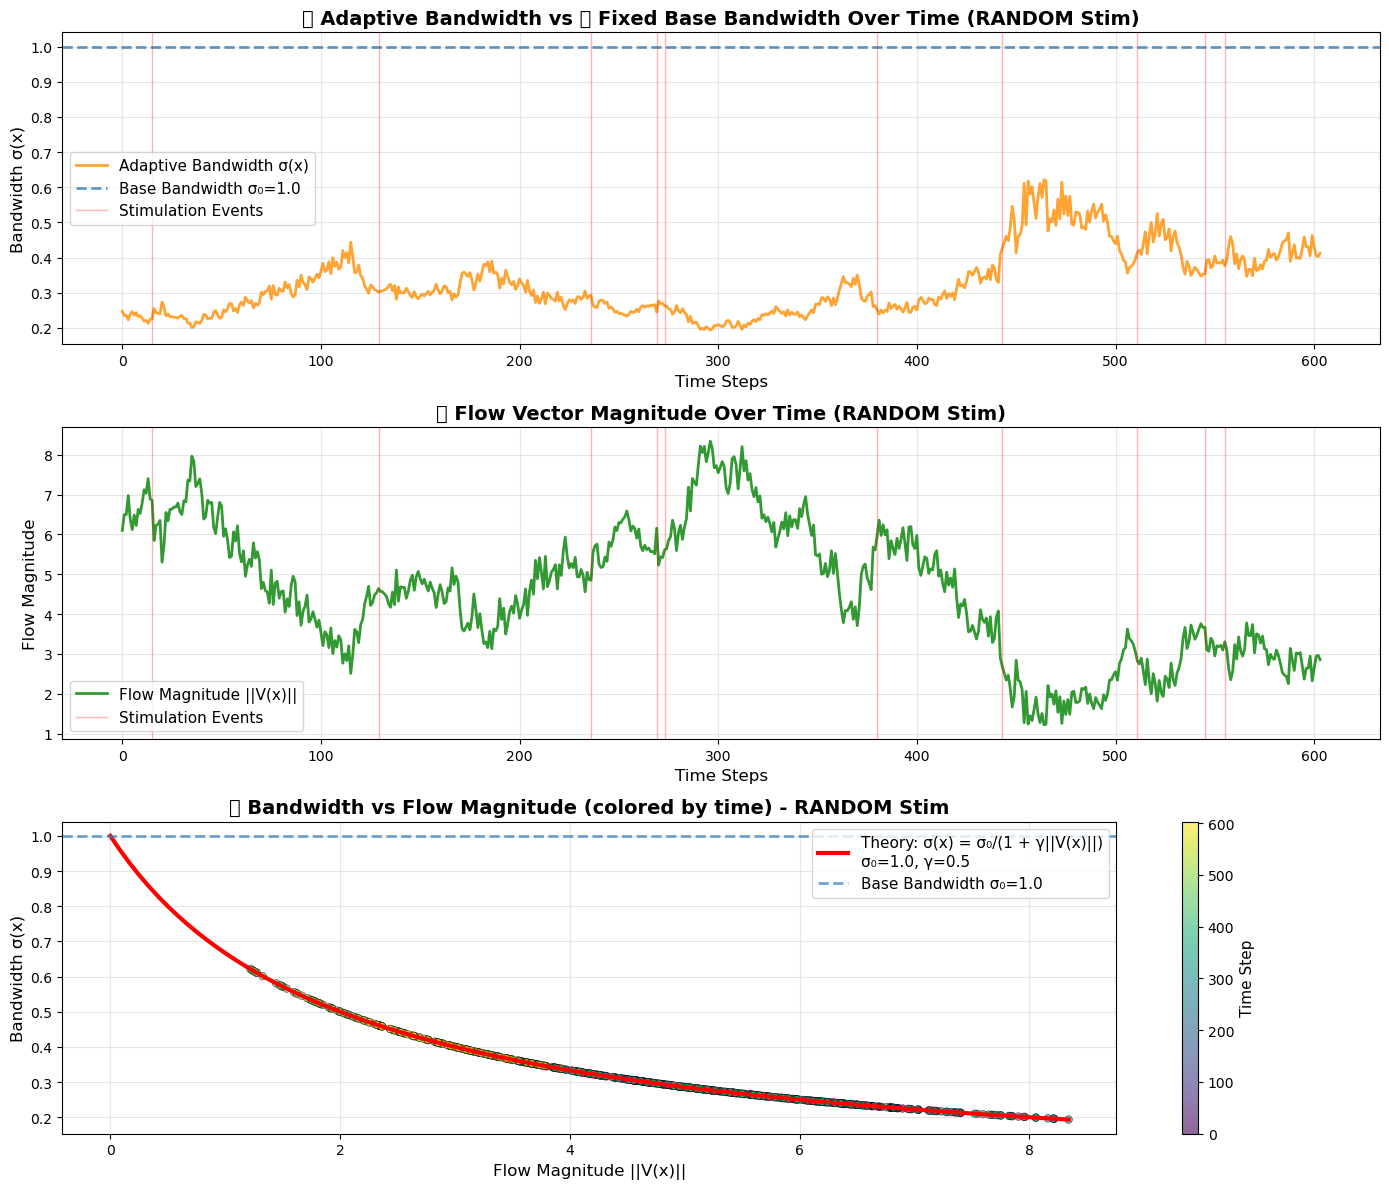


📊 Bandwidth Analysis Summary (RANDOM Stimulation):
   Base bandwidth σ₀: 1.000
   Flow sensitivity γ: 0.500
   Number of stimulation events: 19
   Stim times: [ 15  71 129 216 236 239 269 270 273 366 380 382 443 492 511 516 545 549
 555]

Bandwidth analysis visualization for random stimulation completed successfully!


In [178]:
# Visualize Bandwidth Analysis for Random Stimulation

print("Creating bandwidth analysis plots for RANDOM stimulation...")

# Extract bandwidth and flow data
bandwidth_history_random = np.array(sr_adaptive_bw_random.stim_reg.bandwidth_history)
flow_magnitude_history_random = np.array(sr_adaptive_bw_random.stim_reg.flow_magnitude_history)

# Get the actual experiment length from the data
n_experiment_steps_random = len(stim_bw_random)
print(f"Experiment length: {n_experiment_steps_random} time steps")
print(f"Bandwidth history length: {len(bandwidth_history_random)} entries")

# Trim bandwidth history to match experiment length if needed
if len(bandwidth_history_random) > n_experiment_steps_random:
    print(f"Trimming bandwidth history from {len(bandwidth_history_random)} to {n_experiment_steps_random} to match experiment")
    bandwidth_history_random = bandwidth_history_random[:n_experiment_steps_random]
    flow_magnitude_history_random = flow_magnitude_history_random[:n_experiment_steps_random]

time_steps_random = np.arange(len(bandwidth_history_random))

# Extract ACTUAL stimulation times from raw stim data
stim_data_bw_array = np.array(stim_bw_random.data)
actual_stim_times_random = np.where(stim_data_bw_array.flatten() != 0)[0]

print(f"Found {len(actual_stim_times_random)} actual stimulation events")

# Create figure with 3 subplots
fig_random, (ax1_r, ax2_r, ax3_r) = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Bandwidth over time
ax1_r.plot(time_steps_random, bandwidth_history_random, 'darkorange', linewidth=2, label='Adaptive Bandwidth σ(x)', alpha=0.8)
ax1_r.axhline(y=sr_adaptive_bw_random.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Base Bandwidth σ₀={sr_adaptive_bw_random.stim_reg.sigma_0}')

# Add ACTUAL stimulation event markers
for i, st in enumerate(actual_stim_times_random[::2]):  # Every 2nd to avoid clutter
    if st < len(bandwidth_history_random):  # Only if within tracking range
        if i == 0:
            ax1_r.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1, label='Stimulation Events')
        else:
            ax1_r.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1)

ax1_r.set_xlabel('Time Steps', fontsize=12)
ax1_r.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax1_r.set_title('🟠 Adaptive Bandwidth vs 🔵 Fixed Base Bandwidth Over Time (RANDOM Stim)', fontsize=14, fontweight='bold')
ax1_r.legend(fontsize=11)
ax1_r.grid(True, alpha=0.3)

# Plot 2: Flow magnitude over time
ax2_r.plot(time_steps_random, flow_magnitude_history_random, 'green', linewidth=2, label='Flow Magnitude ||V(x)||', alpha=0.8)

# Add ACTUAL stimulation event markers
for i, st in enumerate(actual_stim_times_random[::2]):
    if st < len(bandwidth_history_random):
        if i == 0:
            ax2_r.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1, label='Stimulation Events')
        else:
            ax2_r.axvline(x=st, color='red', alpha=0.3, linestyle='-', linewidth=1)

ax2_r.set_xlabel('Time Steps', fontsize=12)
ax2_r.set_ylabel('Flow Magnitude', fontsize=12)
ax2_r.set_title('🟢 Flow Vector Magnitude Over Time (RANDOM Stim)', fontsize=14, fontweight='bold')
ax2_r.legend(fontsize=11)
ax2_r.grid(True, alpha=0.3)

# Plot 3: Bandwidth vs Flow Magnitude scatter
scatter_random = ax3_r.scatter(flow_magnitude_history_random, bandwidth_history_random, alpha=0.6, s=30, 
                     c=time_steps_random, cmap='viridis', edgecolors='black', linewidth=0.5)

# Show theoretical relationship
flow_range_random = np.linspace(0, np.max(flow_magnitude_history_random), 100)
theoretical_bandwidth_random = sr_adaptive_bw_random.stim_reg.sigma_0 / (1 + sr_adaptive_bw_random.stim_reg.gamma * flow_range_random)
ax3_r.plot(flow_range_random, theoretical_bandwidth_random, 'r-', linewidth=3, 
         label=f'Theory: σ(x) = σ₀/(1 + γ||V(x)||)\nσ₀={sr_adaptive_bw_random.stim_reg.sigma_0}, γ={sr_adaptive_bw_random.stim_reg.gamma}')

# Add base bandwidth reference line
ax3_r.axhline(y=sr_adaptive_bw_random.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Base Bandwidth σ₀={sr_adaptive_bw_random.stim_reg.sigma_0}')

ax3_r.set_xlabel('Flow Magnitude ||V(x)||', fontsize=12)
ax3_r.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax3_r.set_title('🟡 Bandwidth vs Flow Magnitude (colored by time) - RANDOM Stim', fontsize=14, fontweight='bold')
ax3_r.legend(fontsize=11, loc='upper right')
ax3_r.grid(True, alpha=0.3)

# Add colorbar
cbar_random = plt.colorbar(scatter_random, ax=ax3_r)
cbar_random.set_label('Time Step', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n📊 Bandwidth Analysis Summary (RANDOM Stimulation):")
print(f"   Base bandwidth σ₀: {sr_adaptive_bw_random.stim_reg.sigma_0:.3f}")
print(f"   Flow sensitivity γ: {sr_adaptive_bw_random.stim_reg.gamma:.3f}")
print(f"   Number of stimulation events: {len(actual_stim_times_random)}")
print(f"   Stim times: {actual_stim_times_random}")

print("\nBandwidth analysis visualization for random stimulation completed successfully!")

In [179]:
# Check the actual stim array
print("Examining the raw stim array...")
print(f"Total length of stim_bw: {len(stim_bw)}")
print(f"stim_bw.data shape: {stim_bw.data.shape}")

# Convert to numpy array
stim_data_array = np.array(stim_bw.data)

# Count non-zero stims
non_zero_indices = np.where(stim_data_array.flatten() != 0)[0]
print(f"Number of non-zero stims: {len(non_zero_indices)}")
print(f"\nFirst 30 non-zero stim times:")
print(non_zero_indices[:30])



Examining the raw stim array...
Total length of stim_bw: 606
stim_bw.data shape: (606, 1)
Number of non-zero stims: 19

First 30 non-zero stim times:
[ 24  80 142 160 170 175 192 200 257 301 303 304 323 330 366 383 393 569
 578]


# Bursts experiment

## Burst Stimulation Experiment

This section tests an experiment where stimulations come in concentrated bursts of 10 stimulations each. This differs from the distributed stimulation pattern used in previous experiments.

**Experiment Setup:**
- Stimulations come in bursts of 10 consecutive stims
- Uses the same curvy dynamics as previous experiments
- Compares Base Kernel vs Adaptive Kernel regressors

In [200]:
# Simplified burst stimulation approach - reuse existing LDS structure

def create_burst_adaptive_comparison_srs_simple(rng, burst_size=10, burst_stims_per_rotation=5):
    """
    Create stimulus regressors comparing base and adaptive kernel methods with burst stims.
    Simplified to directly modify the stimulation array from LDS output.
    """
    # First, generate data using the standard LDS approach with more stims
    _, Y, stim_original = LDS.run_nest_dynamical_system(
        n_rotations, 
        stims_per_rotation=burst_stims_per_rotation,  # Use burst-specific parameter
        stim_magnitude=stim_magnitude, 
        rng=rng, 
        u_function='curvy', 
        noise=noise_variance
    )
    
    # Now modify the stimulation pattern to create bursts
    # Get the indices where stimulations occurred
    stim_indices = np.where(stim_original[:, 0] > 0)[0]
    
    # Create new burst pattern
    N = len(stim_original)
    stim_burst = np.zeros((N, 1))
    
    # Calculate number of bursts - aim for same total stims as original
    total_stims_desired = len(stim_indices)
    num_bursts = max(2, total_stims_desired // burst_size)  # At least 2 bursts
    
    # Place bursts evenly throughout the experiment with spacing
    stim_rng = np.random.default_rng(rng.integers(0, 2**32))
    min_spacing = burst_size * 3  # Minimum spacing between bursts
    
    # Divide time into segments for each burst
    segment_size = N // num_bursts
    
    burst_starts = []
    for i in range(num_bursts):
        # Define segment boundaries
        segment_start = i * segment_size
        segment_end = min((i + 1) * segment_size - burst_size, N - burst_size)
        
        if segment_end > segment_start:
            # Randomly place burst within this segment
            burst_start = stim_rng.integers(segment_start, segment_end)
            burst_starts.append(burst_start)
    
    # Apply bursts
    for start in burst_starts:
        stim_burst[start:start + burst_size, 0] = 1
    
    # Update the stim ArrayWithTime
    stim = ArrayWithTime(stim_burst, stim_original.t)
    
    print(f"Created {len(burst_starts)} bursts of {burst_size} stims ({stim_burst.sum():.0f} total) spread across experiment")
    
    # Create flow vector function (same as before)
    flow_func = create_flow_vector_function()

    # Create stimulus regressor with base multi-kernel regressor
    sr_base = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=BaseMultiKernelRegressor(length_scales=(1.0, 1.0, 1.0), maxlen=100), 
        log_level=2, 
        check_dt=True
    )
    
    # Create stimulus regressor with adaptive multi-kernel regressor
    sr_adaptive = StimRegressorWithExtraLogging(
        autoreg=StreamingKalmanFilter(), 
        stim_reg=AdaptiveMultiKernelRegressor(
            sigma_0=1.0,
            gamma=0.5,
            flow_vector_func=flow_func,
            maxlen=100
        ), 
        log_level=2, 
        check_dt=True
    )

    # Run both regressors on the same data
    pre_srs = {
        'Base Kernel (burst stim)': sr_base, 
        'Adaptive Kernel (burst stim)': sr_adaptive
    }
    
    for sr in pre_srs.values():
        sr.offline_run_on([(Y, 'X'), (stim, 'stim')], convinient_return=False, show_tqdm=False)
        finalize_log(sr, stim)

    return pre_srs

print("Simplified burst stimulation functions defined!")


Simplified burst stimulation functions defined!


In [201]:
# Run burst stimulation experiment directly

print("Generating burst stimulation experiment with base vs adaptive kernel...")
print(f"Configuration: {n_rotations} rotations, bursts of 10 stims, magnitude {stim_magnitude}")

# Create single run directly
srs_burst_adaptive = {'Base Kernel (burst stim)': [], 'Adaptive Kernel (burst stim)': []}

# Generate the data
burst_srs = create_burst_adaptive_comparison_srs_simple(rng, burst_size=10)

# Organize into the expected format
for key in srs_burst_adaptive.keys():
    srs_burst_adaptive[key].append(burst_srs[key])

print("\nBurst experiment data generated successfully!")
print(f"Available regressor types: {list(srs_burst_adaptive.keys())}")

# Display basic statistics
for name, regressor_list in srs_burst_adaptive.items():
    sr = regressor_list[0]  # Get first (and only) run
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating burst stimulation experiment with base vs adaptive kernel...
Configuration: 20 rotations, bursts of 10 stims, magnitude 10
Created 9 bursts of 10 stims (90 total) spread across experiment


Generating burst stimulation experiment with base vs adaptive kernel...
Configuration: 20 rotations, bursts of 10 stims, magnitude 10
Created 9 bursts of 10 stims (90 total) spread across experiment


KeyboardInterrupt: 

In [182]:
# Wrapper function for multiple runs

def make_burst_adaptive_comparison_srs(rng, burst_size=10, burst_stims_per_rotation=5, n_runs=1, show_tqdm=False):
    """Create multiple runs of burst adaptive comparison and organize by type."""
    srs = []
    iterator = tqdm.trange(n_runs, desc="Generating burst adaptive comparison runs") if show_tqdm else range(n_runs)
    
    for _ in iterator:
        srs.append(create_burst_adaptive_comparison_srs_simple(rng, burst_size=burst_size, 
                                                                burst_stims_per_rotation=burst_stims_per_rotation))

    # Reorganize data by regressor type
    srs = {k: [run[k] for run in srs] for k in srs[0].keys()}
    return srs

print("Burst adaptive comparison wrapper function defined successfully!")

Burst adaptive comparison wrapper function defined successfully!


In [183]:
# Configure burst experiment parameters
# Increase stims_per_rotation for this experiment to have more bursts
burst_stims_per_rotation = 5  # This will give us ~100 total stims, allowing for ~10 bursts of 10
burst_size = 10

print(f"Burst experiment configuration:")
print(f"  - Rotations: {n_rotations}")
print(f"  - Stims per rotation: {burst_stims_per_rotation}")
print(f"  - Expected total stims: {n_rotations * burst_stims_per_rotation}")
print(f"  - Burst size: {burst_size}")
print(f"  - Expected number of bursts: ~{(n_rotations * burst_stims_per_rotation) // burst_size}")

Burst experiment configuration:
  - Rotations: 20
  - Stims per rotation: 5
  - Expected total stims: 100
  - Burst size: 10
  - Expected number of bursts: ~10


In [204]:
# Run burst stimulation experiment

print("Generating burst stimulation experiment with base vs adaptive kernel...")
print(f"Configuration: {n_rotations} rotations, bursts of {burst_size} stims, magnitude {stim_magnitude}")

srs_burst_adaptive = make_burst_adaptive_comparison_srs(rng, burst_size=burst_size, 
                                                         burst_stims_per_rotation=burst_stims_per_rotation,
                                                         n_runs=1, show_tqdm=True)

print("\nBurst experiment data generated successfully!")
print(f"Available regressor types: {list(srs_burst_adaptive.keys())}")

# Display basic statistics
for name, regressor_list in srs_burst_adaptive.items():
    sr = regressor_list[0]  # Get first (and only) run
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors, axis=1)):.4f}")

Generating burst stimulation experiment with base vs adaptive kernel...
Configuration: 20 rotations, bursts of 10 stims, magnitude 10


Generating burst stimulation experiment with base vs adaptive kernel...
Configuration: 20 rotations, bursts of 10 stims, magnitude 10


Generating burst adaptive comparison runs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating burst stimulation experiment with base vs adaptive kernel...
Configuration: 20 rotations, bursts of 10 stims, magnitude 10


Generating burst adaptive comparison runs:   0%|          | 0/1 [00:00<?, ?it/s]

Created 9 bursts of 10 stims (90 total) spread across experiment

Burst experiment data generated successfully!
Available regressor types: ['Base Kernel (burst stim)', 'Adaptive Kernel (burst stim)']

Base Kernel (burst stim):
  - Total prediction errors logged: 562
  - Mean prediction error: nan
  - Std prediction error: nan

Adaptive Kernel (burst stim):
  - Total prediction errors logged: 562
  - Mean prediction error: nan
  - Std prediction error: nan

Burst experiment data generated successfully!
Available regressor types: ['Base Kernel (burst stim)', 'Adaptive Kernel (burst stim)']

Base Kernel (burst stim):
  - Total prediction errors logged: 562
  - Mean prediction error: nan
  - Std prediction error: nan

Adaptive Kernel (burst stim):
  - Total prediction errors logged: 562
  - Mean prediction error: nan
  - Std prediction error: nan


Creating burst experiment prediction error plot...
Plotting all-time prediction errors...
Plotting post-stim prediction errors...


Creating burst experiment prediction error plot...
Plotting all-time prediction errors...
Plotting post-stim prediction errors...


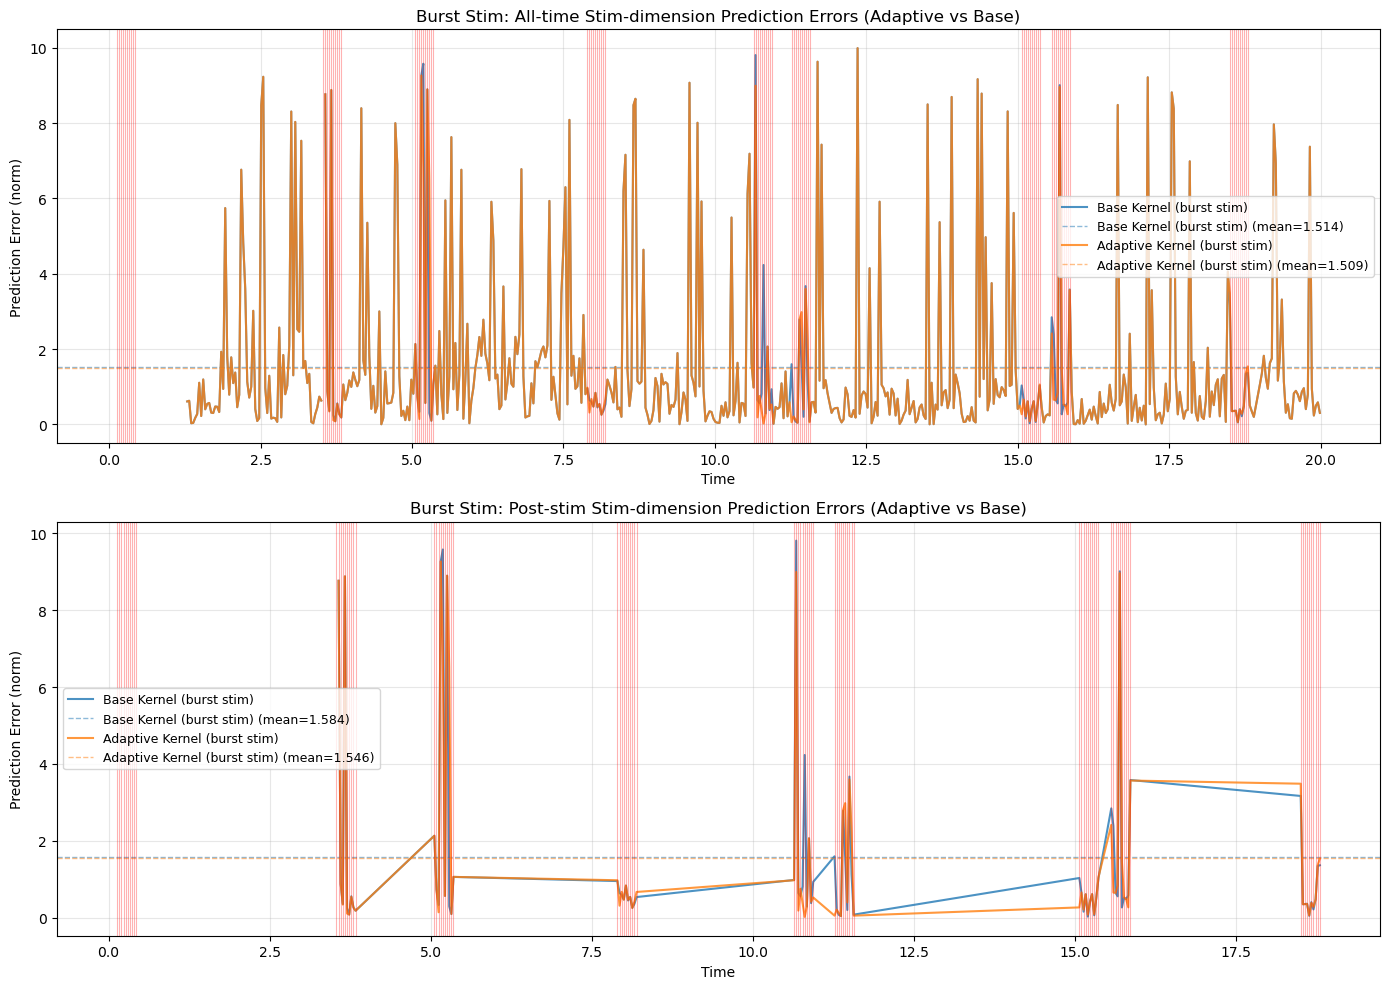

Burst experiment prediction error plot created successfully!

Note: Red vertical lines indicate stimulation times (burst of 10 stims)


In [185]:
# Visualize burst experiment prediction errors with stim markers

print("Creating burst experiment prediction error plot...")

# Create figure with subplots
fig_burst_adaptive, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Define colors for the two methods
colors = {'Base Kernel (burst stim)': '#1f77b4', 'Adaptive Kernel (burst stim)': '#ff7f0e'}

# Get stimulation times from the first regressor
first_sr = list(srs_burst_adaptive.values())[0][0]
if 'stim_intended_samples' in first_sr.log:
    stim_samples = first_sr.log['stim_intended_samples']
    stim_times = stim_samples.t  # Time points where stims occurred

# Plot 1: All-time prediction errors (stimulation dimension only)
print("Plotting all-time prediction errors...")
for method_name, regressor_list in srs_burst_adaptive.items():
    sr = regressor_list[0]
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        times = pred_errors.t
        
        # Extract stimulation dimension (dimension index 2)
        errors_stim_dim = np.array([np.abs(error[2]) for error in pred_errors])
        
        # Plot the errors
        ax1.plot(times, errors_stim_dim, label=method_name, 
                color=colors[method_name], linewidth=1.5, alpha=0.8)
        
        # Add mean line for all-time errors
        mean_error_all = np.nanmean(errors_stim_dim)
        ax1.axhline(mean_error_all, color=colors[method_name], linestyle='--', 
                   alpha=0.5, linewidth=1, label=f'{method_name} (mean={mean_error_all:.3f})')

# Add vertical lines for stimulation times
if 'stim_intended_samples' in first_sr.log:
    for stim_time in stim_times:
        ax1.axvline(stim_time, color='red', alpha=0.3, linewidth=0.8, linestyle='-')

ax1.set_title('Burst Stim: All-time Stim-dimension Prediction Errors (Adaptive vs Base)', fontsize=12)
ax1.set_xlabel('Time', fontsize=10)
ax1.set_ylabel('Prediction Error (norm)', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Post-stimulation prediction errors only
print("Plotting post-stim prediction errors...")
for method_name, regressor_list in srs_burst_adaptive.items():
    sr = regressor_list[0]
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        stim_samples = sr.log['stim_intended_samples']
        
        # Align to get only post-stim errors
        _, post_stim_errors = ArrayWithTime.align_indices(stim_samples, pred_errors)
        
        if len(post_stim_errors) > 0:
            times_post = post_stim_errors.t
            # Extract stimulation dimension
            errors_stim_dim = np.array([np.abs(error[2]) for error in post_stim_errors])
            
            # Plot the errors
            ax2.plot(times_post, errors_stim_dim, label=method_name, 
                    color=colors[method_name], linewidth=1.5, alpha=0.8)
            
            # Add mean line
            mean_error = np.nanmean(errors_stim_dim)
            ax2.axhline(mean_error, color=colors[method_name], linestyle='--', 
                       alpha=0.5, linewidth=1, label=f'{method_name} (mean={mean_error:.3f})')

# Add vertical lines for stimulation times
if 'stim_intended_samples' in first_sr.log:
    for stim_time in stim_times:
        ax2.axvline(stim_time, color='red', alpha=0.3, linewidth=0.8, linestyle='-')

ax2.set_title('Burst Stim: Post-stim Stim-dimension Prediction Errors (Adaptive vs Base)', fontsize=12)
ax2.set_xlabel('Time', fontsize=10)
ax2.set_ylabel('Prediction Error (norm)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Burst experiment prediction error plot created successfully!")
print(f"\nNote: Red vertical lines indicate stimulation times (burst of {10} stims)")

## Bandwidth Analysis for Burst Stimulation

Analyze how the adaptive kernel's bandwidth changes during burst stimulation patterns. This shows how the kernel adapts to local flow dynamics at the training points.

In [186]:
# Need to define AdaptiveMultiKernelRegressorWithTracking for burst experiment

class AdaptiveMultiKernelRegressorWithTracking(AdaptiveMultiKernelRegressor):
    """Extended version that tracks bandwidth and flow history."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.bandwidth_history = []
        self.flow_magnitude_history = []
    
    def observe(self, x, y):
        """Override observe to track bandwidth history."""
        try:
            # Calculate flow and bandwidth at this training point
            if isinstance(x, (list, tuple)):
                full_x_vector = np.concatenate([np.array(sub_x).flatten() for sub_x in x])
            else:
                full_x_vector = np.array(x).flatten()
            
            full_x_vector_jax = jnp.array(full_x_vector)
            flow_vector = self.flow_vector_func(full_x_vector_jax)
            flow_vector_np = np.array(flow_vector)
            flow_magnitude = np.linalg.norm(flow_vector_np)
            
            if np.isnan(flow_magnitude) or np.isinf(flow_magnitude):
                adaptive_bandwidth = self.sigma_0
            else:
                adaptive_bandwidth = self.sigma_0 / (1 + self.gamma * flow_magnitude)
            
            # Track the values
            self.bandwidth_history.append(float(adaptive_bandwidth))
            self.flow_magnitude_history.append(float(flow_magnitude))
            
        except Exception as e:
            self.bandwidth_history.append(float(self.sigma_0))
            self.flow_magnitude_history.append(0.0)
        
        # Call parent observe
        super().observe(x, y)

print("AdaptiveMultiKernelRegressorWithTracking defined for burst experiment!")

AdaptiveMultiKernelRegressorWithTracking defined for burst experiment!


In [187]:
# Generate Burst Stimulation Data with Bandwidth Tracking

print("Generating adaptive regressor with bandwidth tracking for BURST stimulation...")

# Generate synthetic neural data with BURST stimulation
_, Y_bw_burst, stim_original_burst = LDS.run_nest_dynamical_system(
    n_rotations, 
    stims_per_rotation=burst_stims_per_rotation,
    stim_magnitude=stim_magnitude, 
    rng=rng, 
    u_function='curvy',
    noise=noise_variance
)

# Create burst pattern
N_burst = len(stim_original_burst)
stim_burst_bw = np.zeros((N_burst, 1))

# Calculate number of bursts
total_stims_desired_burst = burst_stims_per_rotation * n_rotations
num_bursts_bw = max(2, total_stims_desired_burst // burst_size)

# Place bursts evenly throughout
segment_size_bw = N_burst // num_bursts_bw
burst_starts_bw = []
for i in range(num_bursts_bw):
    segment_start = i * segment_size_bw
    segment_end = min((i + 1) * segment_size_bw - burst_size, N_burst - burst_size)
    if segment_end > segment_start:
        burst_start = rng.integers(segment_start, segment_end)
        burst_starts_bw.append(burst_start)

for start in burst_starts_bw:
    stim_burst_bw[start:start + burst_size, 0] = 1

stim_bw_burst = ArrayWithTime(stim_burst_bw, stim_original_burst.t)

print(f"Created {len(burst_starts_bw)} bursts of {burst_size} stims ({stim_burst_bw.sum():.0f} total)")

# Create flow vector function
flow_func_burst = create_flow_vector_function()

# Create stimulus regressor with bandwidth tracking
sr_adaptive_bw_burst = StimRegressorWithExtraLogging(
    autoreg=StreamingKalmanFilter(), 
    stim_reg=AdaptiveMultiKernelRegressorWithTracking(
        sigma_0=1.0,
        gamma=0.5,
        flow_vector_func=flow_func_burst,
        maxlen=100
    ), 
    log_level=2, 
    check_dt=True
)

# Run the regressor
sr_adaptive_bw_burst.offline_run_on([(Y_bw_burst, 'X'), (stim_bw_burst, 'stim')], convinient_return=False, show_tqdm=False)
finalize_log(sr_adaptive_bw_burst, stim_bw_burst)

print("Bandwidth tracking data for burst stimulation generated successfully!")
print(f"Tracked {len(sr_adaptive_bw_burst.stim_reg.bandwidth_history)} bandwidth values")

Generating adaptive regressor with bandwidth tracking for BURST stimulation...
Created 10 bursts of 10 stims (100 total)


Generating adaptive regressor with bandwidth tracking for BURST stimulation...
Created 10 bursts of 10 stims (100 total)


Bandwidth tracking data for burst stimulation generated successfully!
Tracked 100 bandwidth values


Creating bandwidth analysis plots for BURST stimulation...
Experiment length: 606 time steps
Bandwidth history length: 100 entries
Found 100 actual stimulation events in bursts


Creating bandwidth analysis plots for BURST stimulation...
Experiment length: 606 time steps
Bandwidth history length: 100 entries
Found 100 actual stimulation events in bursts


/tmp/ipykernel_94749/1417627729.py:95: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/1417627729.py:95: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/1417627729.py:95: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/1417627729.py:95: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


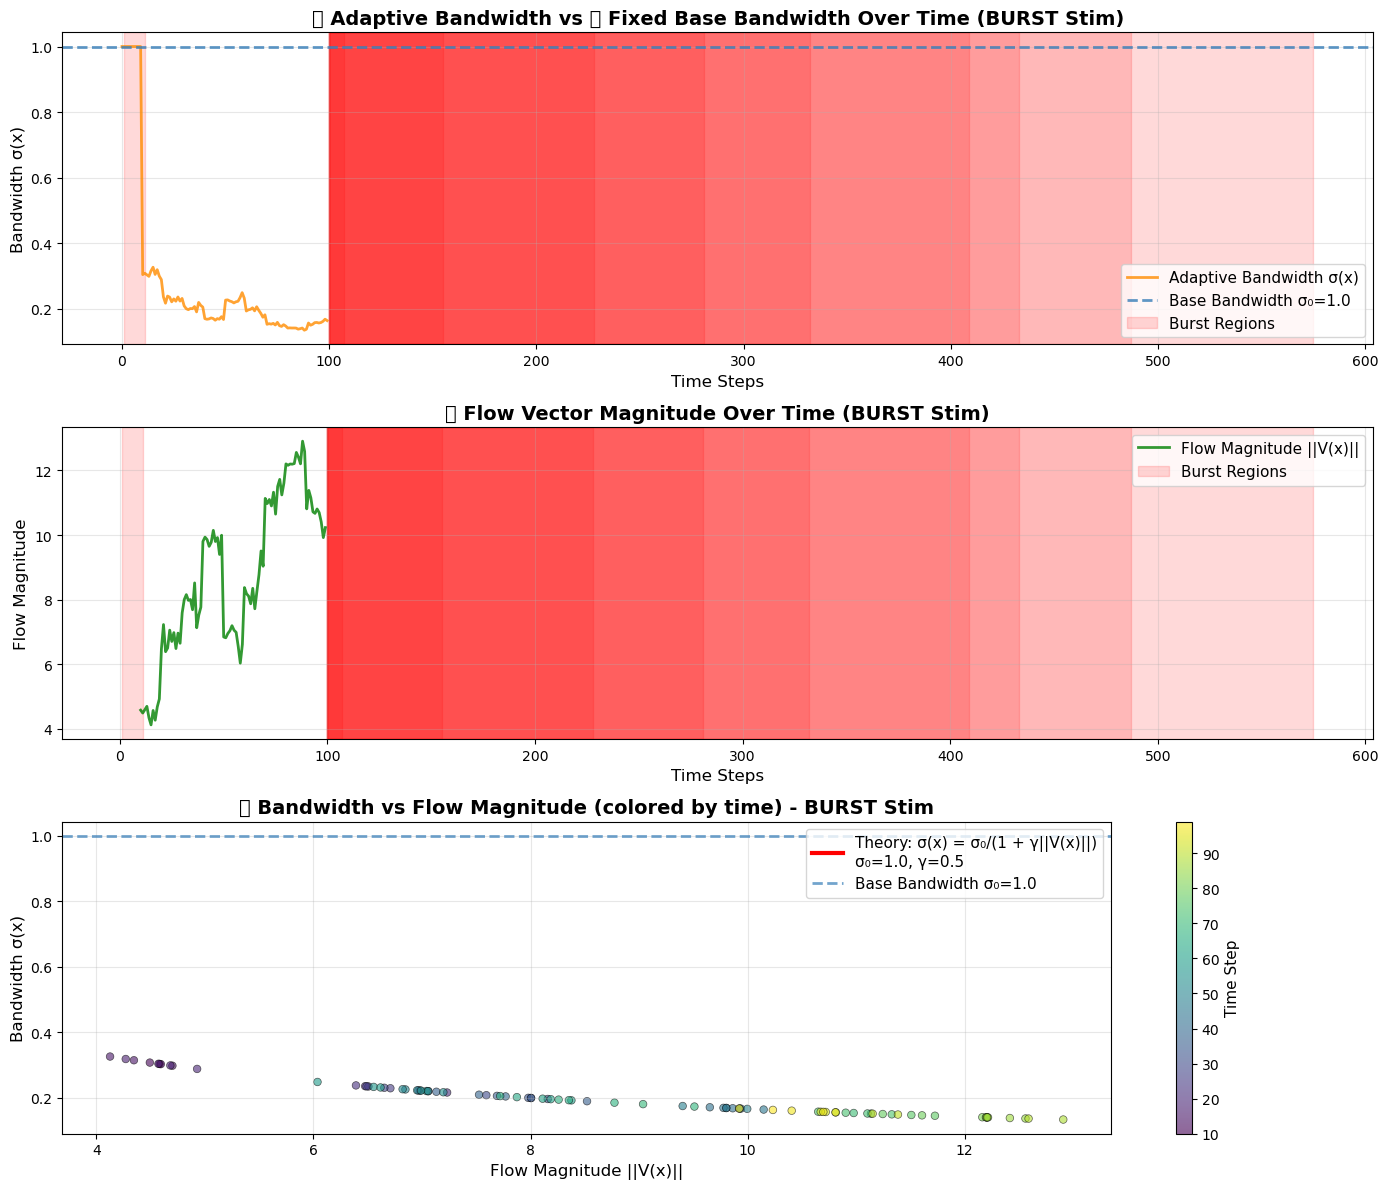


📊 Bandwidth Analysis Summary (BURST Stimulation):
   Base bandwidth σ₀: 1.000
   Flow sensitivity γ: 0.500
   Number of bursts: 10
   Total stimulation events: 100
   Stims per burst: 10
   Mean bandwidth: 0.278
   Std bandwidth: 0.245
   Mean flow magnitude: nan

Bandwidth analysis visualization for burst stimulation completed successfully!


In [188]:
# Visualize Bandwidth Analysis for Burst Stimulation

print("Creating bandwidth analysis plots for BURST stimulation...")

# Extract bandwidth and flow data
bandwidth_history_burst = np.array(sr_adaptive_bw_burst.stim_reg.bandwidth_history)
flow_magnitude_history_burst = np.array(sr_adaptive_bw_burst.stim_reg.flow_magnitude_history)

# Get the actual experiment length from the data
n_experiment_steps_burst = len(stim_bw_burst)
print(f"Experiment length: {n_experiment_steps_burst} time steps")
print(f"Bandwidth history length: {len(bandwidth_history_burst)} entries")

# Trim bandwidth history to match experiment length if needed
if len(bandwidth_history_burst) > n_experiment_steps_burst:
    print(f"Trimming bandwidth history from {len(bandwidth_history_burst)} to {n_experiment_steps_burst}")
    bandwidth_history_burst = bandwidth_history_burst[:n_experiment_steps_burst]
    flow_magnitude_history_burst = flow_magnitude_history_burst[:n_experiment_steps_burst]

time_steps_burst = np.arange(len(bandwidth_history_burst))

# Extract ACTUAL burst stimulation times
stim_data_burst_array = np.array(stim_bw_burst.data)
actual_burst_times = np.where(stim_data_burst_array.flatten() != 0)[0]

print(f"Found {len(actual_burst_times)} actual stimulation events in bursts")

# Create figure with 3 subplots
fig_burst_bw, (ax1_b, ax2_b, ax3_b) = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Bandwidth over time
ax1_b.plot(time_steps_burst, bandwidth_history_burst, 'darkorange', linewidth=2, 
          label='Adaptive Bandwidth σ(x)', alpha=0.8)
ax1_b.axhline(y=sr_adaptive_bw_burst.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
             linewidth=2, alpha=0.8, label=f'Base Bandwidth σ₀={sr_adaptive_bw_burst.stim_reg.sigma_0}')

# Add burst markers (mark burst regions)
for i, burst_start in enumerate(burst_starts_bw):
    burst_end = min(burst_start + burst_size, len(bandwidth_history_burst))
    if i == 0:
        ax1_b.axvspan(burst_start, burst_end, color='red', alpha=0.15, label='Burst Regions')
    else:
        ax1_b.axvspan(burst_start, burst_end, color='red', alpha=0.15)

ax1_b.set_xlabel('Time Steps', fontsize=12)
ax1_b.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax1_b.set_title('🟠 Adaptive Bandwidth vs 🔵 Fixed Base Bandwidth Over Time (BURST Stim)', 
               fontsize=14, fontweight='bold')
ax1_b.legend(fontsize=11)
ax1_b.grid(True, alpha=0.3)

# Plot 2: Flow magnitude over time
ax2_b.plot(time_steps_burst, flow_magnitude_history_burst, 'green', linewidth=2, 
          label='Flow Magnitude ||V(x)||', alpha=0.8)

# Add burst markers
for i, burst_start in enumerate(burst_starts_bw):
    burst_end = min(burst_start + burst_size, len(bandwidth_history_burst))
    if i == 0:
        ax2_b.axvspan(burst_start, burst_end, color='red', alpha=0.15, label='Burst Regions')
    else:
        ax2_b.axvspan(burst_start, burst_end, color='red', alpha=0.15)

ax2_b.set_xlabel('Time Steps', fontsize=12)
ax2_b.set_ylabel('Flow Magnitude', fontsize=12)
ax2_b.set_title('🟢 Flow Vector Magnitude Over Time (BURST Stim)', fontsize=14, fontweight='bold')
ax2_b.legend(fontsize=11)
ax2_b.grid(True, alpha=0.3)

# Plot 3: Bandwidth vs Flow Magnitude scatter
scatter_burst = ax3_b.scatter(flow_magnitude_history_burst, bandwidth_history_burst, alpha=0.6, s=30, 
                              c=time_steps_burst, cmap='viridis', edgecolors='black', linewidth=0.5)

# Show theoretical relationship
flow_range_burst = np.linspace(0, np.max(flow_magnitude_history_burst), 100)
theoretical_bandwidth_burst = sr_adaptive_bw_burst.stim_reg.sigma_0 / (1 + sr_adaptive_bw_burst.stim_reg.gamma * flow_range_burst)
ax3_b.plot(flow_range_burst, theoretical_bandwidth_burst, 'r-', linewidth=3, 
          label=f'Theory: σ(x) = σ₀/(1 + γ||V(x)||)\nσ₀={sr_adaptive_bw_burst.stim_reg.sigma_0}, γ={sr_adaptive_bw_burst.stim_reg.gamma}')

# Add base bandwidth reference line
ax3_b.axhline(y=sr_adaptive_bw_burst.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
             linewidth=2, alpha=0.7, label=f'Base Bandwidth σ₀={sr_adaptive_bw_burst.stim_reg.sigma_0}')

ax3_b.set_xlabel('Flow Magnitude ||V(x)||', fontsize=12)
ax3_b.set_ylabel('Bandwidth σ(x)', fontsize=12)
ax3_b.set_title('🟡 Bandwidth vs Flow Magnitude (colored by time) - BURST Stim', 
               fontsize=14, fontweight='bold')
ax3_b.legend(fontsize=11, loc='upper right')
ax3_b.grid(True, alpha=0.3)

# Add colorbar
cbar_burst = plt.colorbar(scatter_burst, ax=ax3_b)
cbar_burst.set_label('Time Step', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n📊 Bandwidth Analysis Summary (BURST Stimulation):")
print(f"   Base bandwidth σ₀: {sr_adaptive_bw_burst.stim_reg.sigma_0:.3f}")
print(f"   Flow sensitivity γ: {sr_adaptive_bw_burst.stim_reg.gamma:.3f}")
print(f"   Number of bursts: {len(burst_starts_bw)}")
print(f"   Total stimulation events: {len(actual_burst_times)}")
print(f"   Stims per burst: {burst_size}")
print(f"   Mean bandwidth: {np.mean(bandwidth_history_burst):.3f}")
print(f"   Std bandwidth: {np.std(bandwidth_history_burst):.3f}")
print(f"   Mean flow magnitude: {np.mean(flow_magnitude_history_burst):.3f}")

print("\nBandwidth analysis visualization for burst stimulation completed successfully!")

## 3D Surface Plot: Ground Truth vs Learned Manifolds (Burst Stimulation)

Visualize the learned stimulation response manifolds for both Base and Adaptive kernel regressors in the burst stimulation experiment, comparing them against the ground truth surface.

**Key aspects:**
- Gray surface: Ground truth stimulus effect S(x) = [0, 0, stim_magnitude * x₀/||x₀,x₁||]
- Colored scatter points: Learned responses at training locations (during bursts)
- Point colors indicate prediction error magnitude

Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold during BURST stimulation



Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold during BURST stimulation



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


Creating 3D surface plots comparing Base vs Adaptive kernel regressors...
This shows how each method learns the stimulation response manifold during BURST stimulation



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


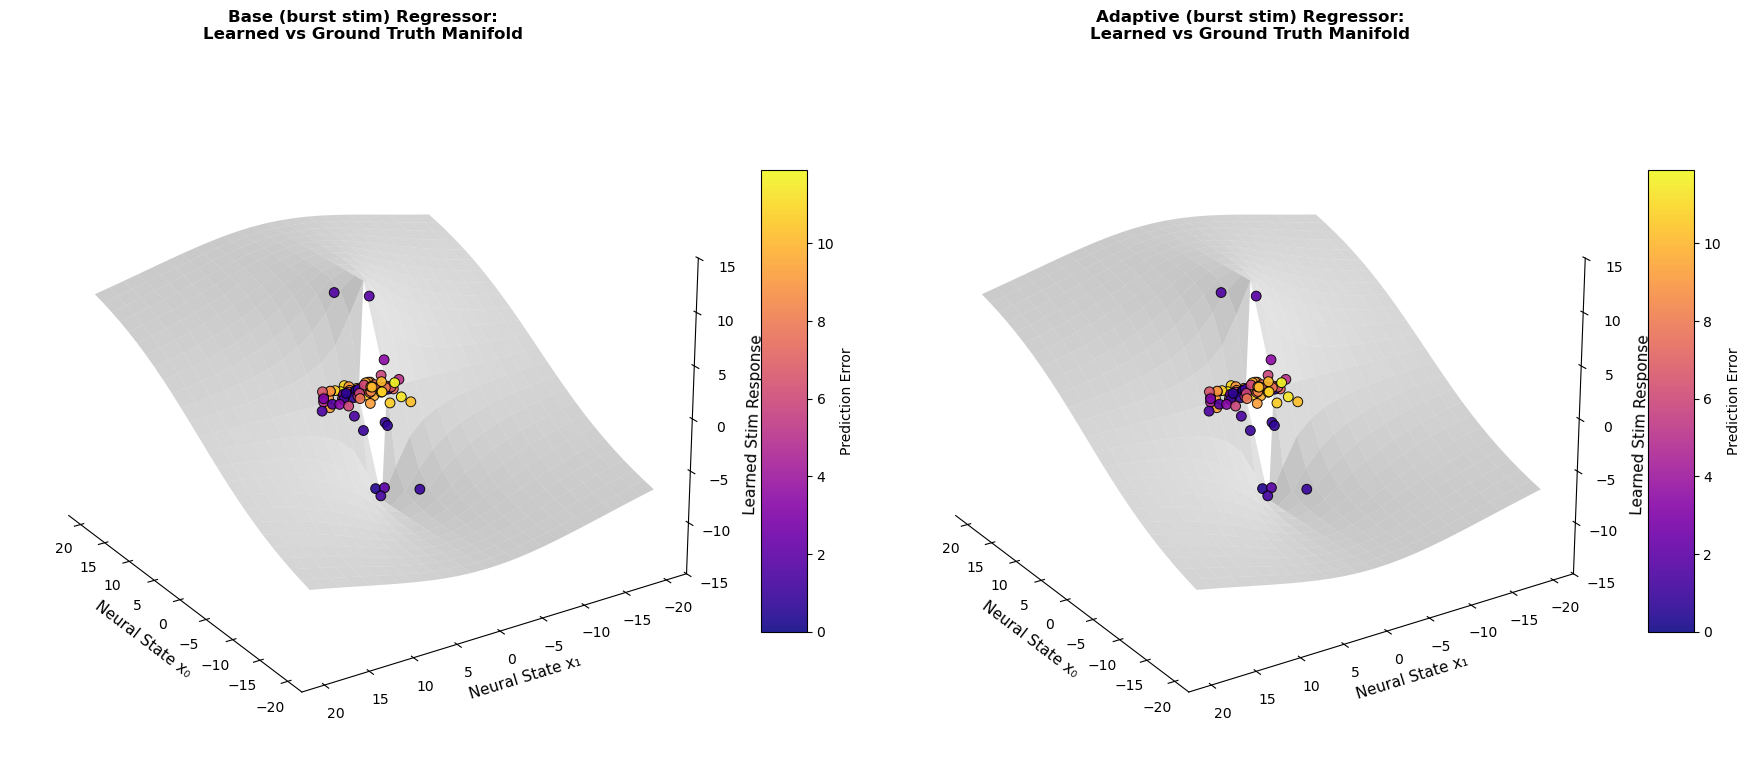


📊 Surface Plot Interpretation:
   - Gray surface: Ground truth stimulus effect
   - Colored points: Learned responses at training locations (burst events)
   - Color indicates prediction error (plasma colormap)
   - Darker (purple) = lower error, Brighter (yellow) = higher error

Burst stimulation uses concentrated patterns (10 stims per burst)
Surface plots created successfully!


In [189]:
# Generate and Display Surface Plots for Burst Stimulation Experiment

print("Creating 3D surface plots comparing Base vs Adaptive kernel regressors...")
print("This shows how each method learns the stimulation response manifold during BURST stimulation\n")

fig_surfaces_burst = create_surface_comparison_plots(srs_burst_adaptive, stim_magnitude=stim_magnitude)
plt.show()

print("\n📊 Surface Plot Interpretation:")
print("   - Gray surface: Ground truth stimulus effect")
print("   - Colored points: Learned responses at training locations (burst events)")
print("   - Color indicates prediction error (plasma colormap)")
print("   - Darker (purple) = lower error, Brighter (yellow) = higher error")
print(f"\nBurst stimulation uses concentrated patterns ({burst_size} stims per burst)")
print("Surface plots created successfully!")



Creating 3D surface plots comparing Base vs Adaptive kernel regressors for FLIP experiment...
This shows how each method learns the stimulation response manifold during FLIP stimulation



Creating 3D surface plots comparing Base vs Adaptive kernel regressors for FLIP experiment...
This shows how each method learns the stimulation response manifold during FLIP stimulation



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


Creating 3D surface plots comparing Base vs Adaptive kernel regressors for FLIP experiment...
This shows how each method learns the stimulation response manifold during FLIP stimulation



/tmp/ipykernel_94749/183812722.py:20: RuntimeWarning: invalid value encountered in scalar divide
  u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])


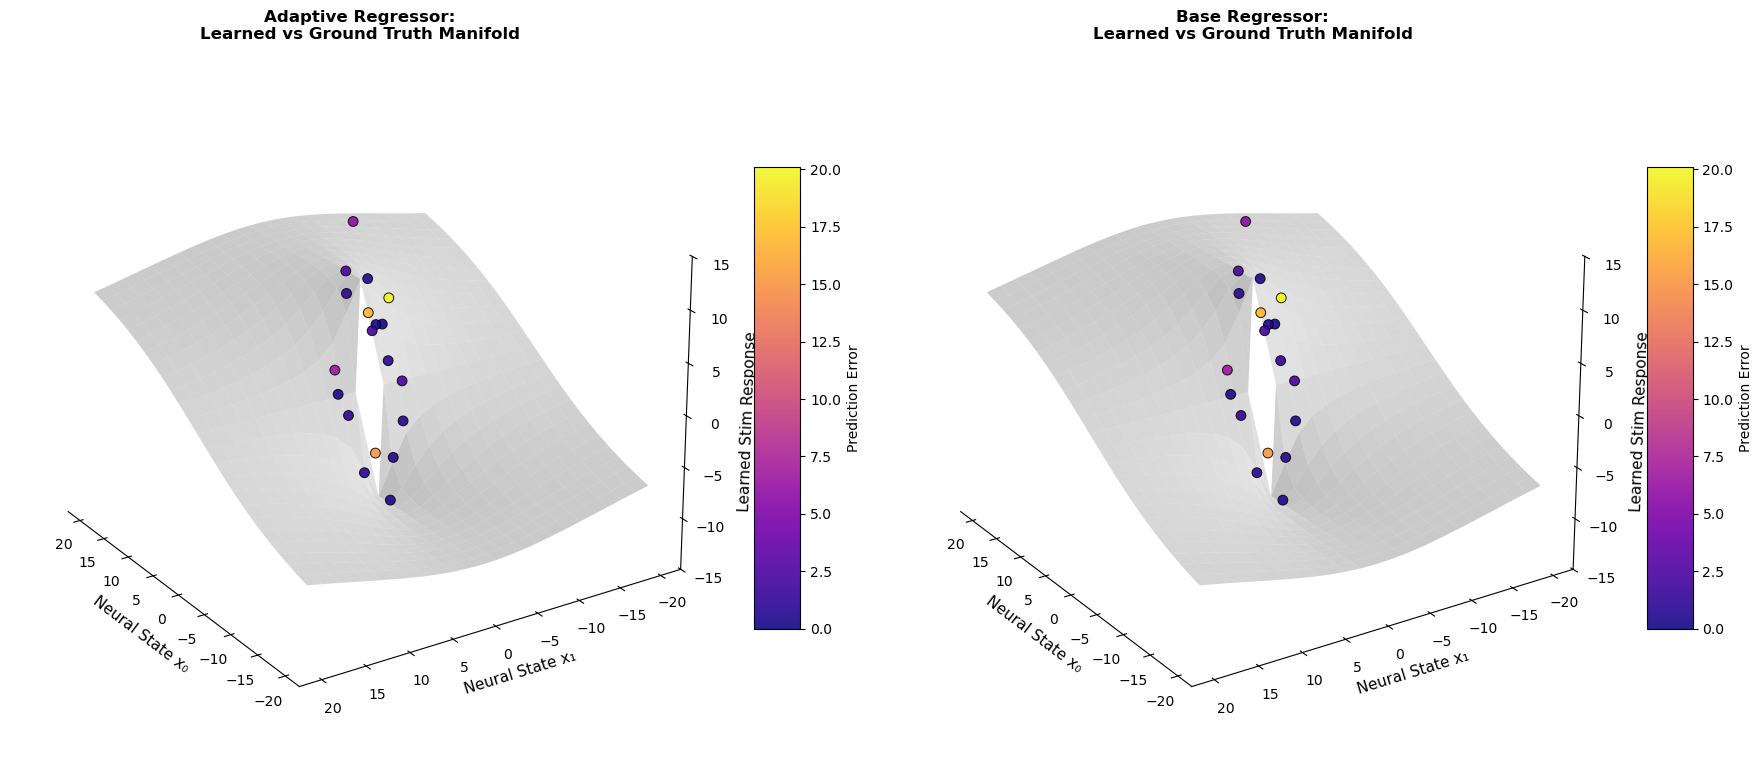


📊 Surface Plot Interpretation:
   - Gray surface: Ground truth stimulus effect
   - Colored points: Learned responses at training locations (flip events)
   - Color indicates prediction error (plasma colormap)
   - Darker (purple) = lower error, Brighter (yellow) = higher error

Flip stimulation involves trajectory reversals
Surface plots created successfully!


In [191]:
# Generate and Display Surface Plots for Flip Stimulation Experiment

print("Creating 3D surface plots comparing Base vs Adaptive kernel regressors for FLIP experiment...")
print("This shows how each method learns the stimulation response manifold during FLIP stimulation\n")

fig_surfaces_flips = create_surface_comparison_plots(srs_curvy_flips, stim_magnitude=stim_magnitude)
plt.show()

print("\n📊 Surface Plot Interpretation:")
print("   - Gray surface: Ground truth stimulus effect")
print("   - Colored points: Learned responses at training locations (flip events)")
print("   - Color indicates prediction error (plasma colormap)")
print("   - Darker (purple) = lower error, Brighter (yellow) = higher error")
print(f"\nFlip stimulation involves trajectory reversals")
print("Surface plots created successfully!")

## Curvy Flips Experiment

Compare adaptive vs base regressor performance when the stimulation effect flips halfway through the experiment. This tests how well each approach handles sudden changes in the stimulus-response relationship.

In [193]:
# Generate Curvy Flips Data and Train Regressors

print("Generating curvy flips experiment data...")

# Generate synthetic neural data with "curvy flips" stimulation
_, Y_curvy_flips, stim_curvy_flips = LDS.run_nest_dynamical_system(
    n_rotations, 
    stims_per_rotation=stims_per_rotation,
    stim_magnitude=stim_magnitude, 
    rng=rng, 
    u_function='curvy flips',  # Use curvy flips
    noise=noise_variance
)

print(f"Generated {len(Y_curvy_flips)} time steps of data")
print(f"Total stimulations: {np.array(stim_curvy_flips.data).sum():.0f}")

# Find flip point (halfway through)
flip_point = len(Y_curvy_flips) // 2
print(f"Flip occurs at time step: {flip_point}")

# Create flow vector function
flow_func_curvy_flips = create_flow_vector_function()

# Create regressors
srs_curvy_flips = {}

# Adaptive regressor WITH BANDWIDTH TRACKING
srs_curvy_flips['Adaptive'] = StimRegressorWithExtraLogging(
    autoreg=StreamingKalmanFilter(), 
    stim_reg=AdaptiveMultiKernelRegressorWithTracking(
        sigma_0=1.0,
        gamma=0.5,
        flow_vector_func=flow_func_curvy_flips,
        maxlen=100
    ), 
    log_level=2, 
    check_dt=True
)

# Base regressor (fixed bandwidth)
srs_curvy_flips['Base'] = StimRegressorWithExtraLogging(
    autoreg=StreamingKalmanFilter(),
    stim_reg=BaseMultiKernelRegressor(length_scales=(1.0, 1.0, 1.0), maxlen=100),
    log_level=2,
    check_dt=True
)

# Train both regressors
for name, sr in srs_curvy_flips.items():
    print(f"Training {name} regressor on curvy flips data...")
    sr.offline_run_on([(Y_curvy_flips, 'X'), (stim_curvy_flips, 'stim')], convinient_return=False, show_tqdm=False)
    finalize_log(sr, stim_curvy_flips)

print("Curvy flips data generation and training completed!")

Generating curvy flips experiment data...
Generated 606 time steps of data
Total stimulations: 19
Flip occurs at time step: 303
Training Adaptive regressor on curvy flips data...


Generating curvy flips experiment data...
Generated 606 time steps of data
Total stimulations: 19
Flip occurs at time step: 303
Training Adaptive regressor on curvy flips data...


Training Base regressor on curvy flips data...
Curvy flips data generation and training completed!
Curvy flips data generation and training completed!


In [194]:
# Display Statistics for Curvy Flips Experiment

print("Curvy Flips Experiment Statistics:")
print(f"Available regressor types: {list(srs_curvy_flips.keys())}")

# Display basic statistics
for name, sr in srs_curvy_flips.items():
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        pred_errors_array = np.array(pred_errors.data)
        print(f"\n{name}:")
        print(f"  - Total prediction errors logged: {len(pred_errors)}")
        print(f"  - Mean prediction error: {np.mean(np.linalg.norm(pred_errors_array, axis=1)):.4f}")
        print(f"  - Std prediction error: {np.std(np.linalg.norm(pred_errors_array, axis=1)):.4f}")

Curvy Flips Experiment Statistics:
Available regressor types: ['Adaptive', 'Base']

Adaptive:
  - Total prediction errors logged: 581
  - Mean prediction error: nan
  - Std prediction error: nan

Base:
  - Total prediction errors logged: 581
  - Mean prediction error: nan
  - Std prediction error: nan


Creating curvy flips comparison plot...
Flip point: 303 (halfway through 606 time steps)
Creating adaptive vs base prediction error plot...


Creating curvy flips comparison plot...
Flip point: 303 (halfway through 606 time steps)
Creating adaptive vs base prediction error plot...


/tmp/ipykernel_94749/3822633231.py:13: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3822633231.py:13: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


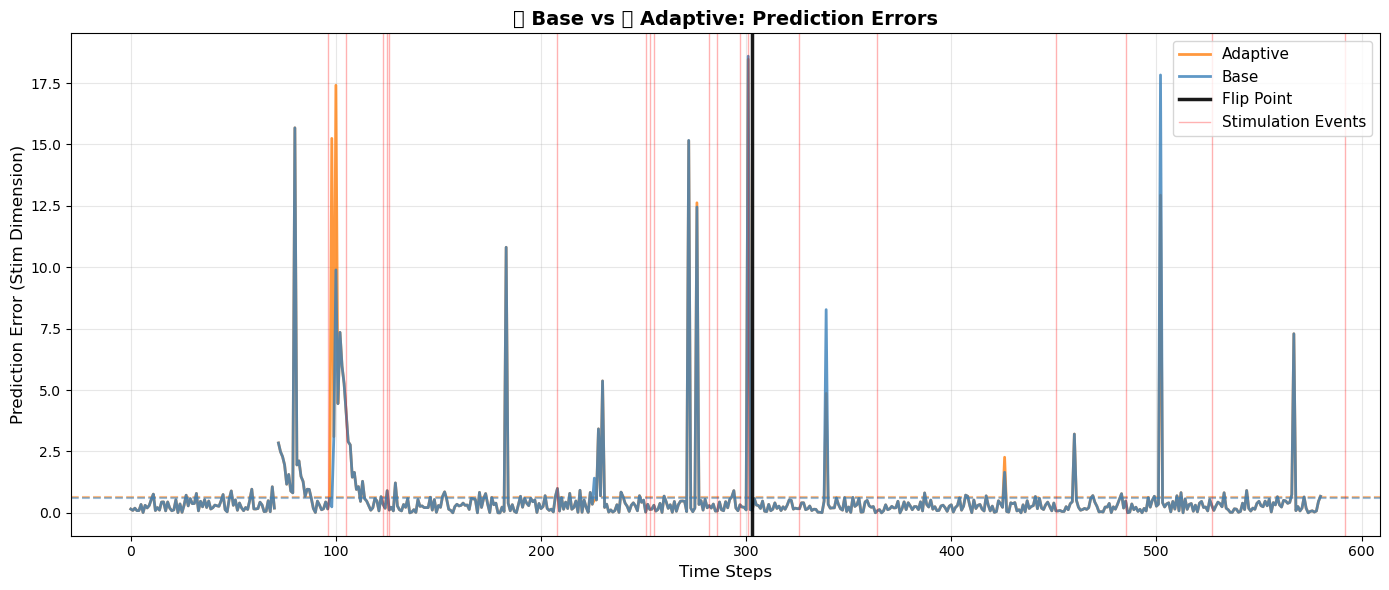


📊 Curvy Flips Experiment Summary:
   Flip point: 303 (time: 10.01)
   Total time steps: 606
   Total stimulations: 19

   Adaptive:
      Before flip MSE: 6.431878
      After flip MSE:  1.043088
      Overall MSE:     3.848975
      Ratio (after/before): 0.162

   Base:
      Before flip MSE: 4.991390
      After flip MSE:  1.737244
      Overall MSE:     3.431644
      Ratio (after/before): 0.348

Curvy flips experiment visualization completed!


In [195]:
# Visualize Curvy Flips Experiment Results

print("Creating curvy flips comparison plot...")
print(f"Flip point: {flip_point} (halfway through {len(Y_curvy_flips)} time steps)")

# Use the plot_adaptive_prediction_errors function
fig_curvy_flips = plot_adaptive_prediction_errors(
    srs_curvy_flips,
    stim_data=stim_curvy_flips,
    flip_point=flip_point
)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n📊 Curvy Flips Experiment Summary:")
print(f"   Flip point: {flip_point} (time: {Y_curvy_flips.t[flip_point]:.2f})")
print(f"   Total time steps: {len(Y_curvy_flips)}")

# Get actual stim count
stim_data_array_cf = np.array(stim_curvy_flips.data)
actual_stim_count = np.sum(stim_data_array_cf != 0)
print(f"   Total stimulations: {actual_stim_count}")

# Compare performance before and after flip
for name, sr in srs_curvy_flips.items():
    if 'pred_error' in sr.log:
        pred_errors = sr.log['pred_error']
        pred_errors_array = np.array(pred_errors.data)
        stim_dim_errors = np.abs(pred_errors_array[:, 2])
        
        # Before flip
        before_errors = stim_dim_errors[:flip_point]
        before_mse = np.nanmean(before_errors**2)
        
        # After flip
        after_errors = stim_dim_errors[flip_point:]
        after_mse = np.nanmean(after_errors**2)
        
        # Overall
        overall_mse = np.nanmean(stim_dim_errors**2)
        
        print(f"\n   {name}:")
        print(f"      Before flip MSE: {before_mse:.6f}")
        print(f"      After flip MSE:  {after_mse:.6f}")
        print(f"      Overall MSE:     {overall_mse:.6f}")
        if before_mse > 0:
            print(f"      Ratio (after/before): {after_mse/before_mse:.3f}")

print("\nCurvy flips experiment visualization completed!")

Creating bandwidth analysis plots for CURVY FLIPS (same run as prediction errors)...
Experiment length: 606 time steps
Bandwidth history length: 19 entries


/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


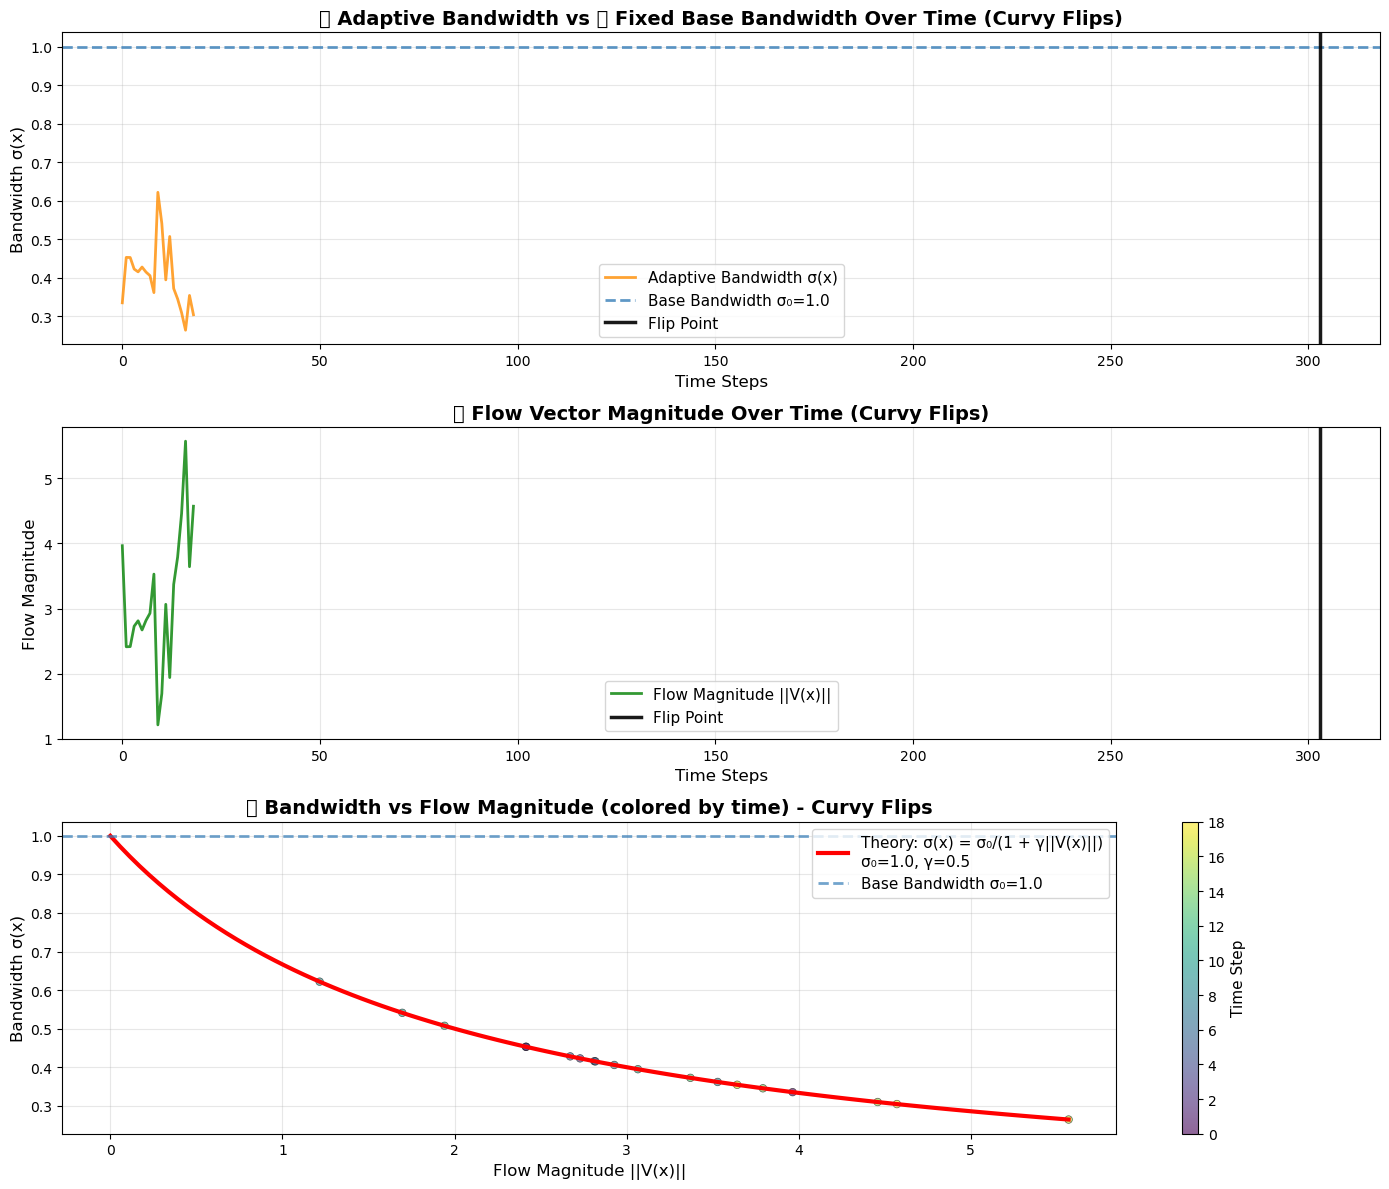

Creating bandwidth analysis plots for CURVY FLIPS (same run as prediction errors)...
Experiment length: 606 time steps
Bandwidth history length: 19 entries


/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_94749/3840802540.py:110: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


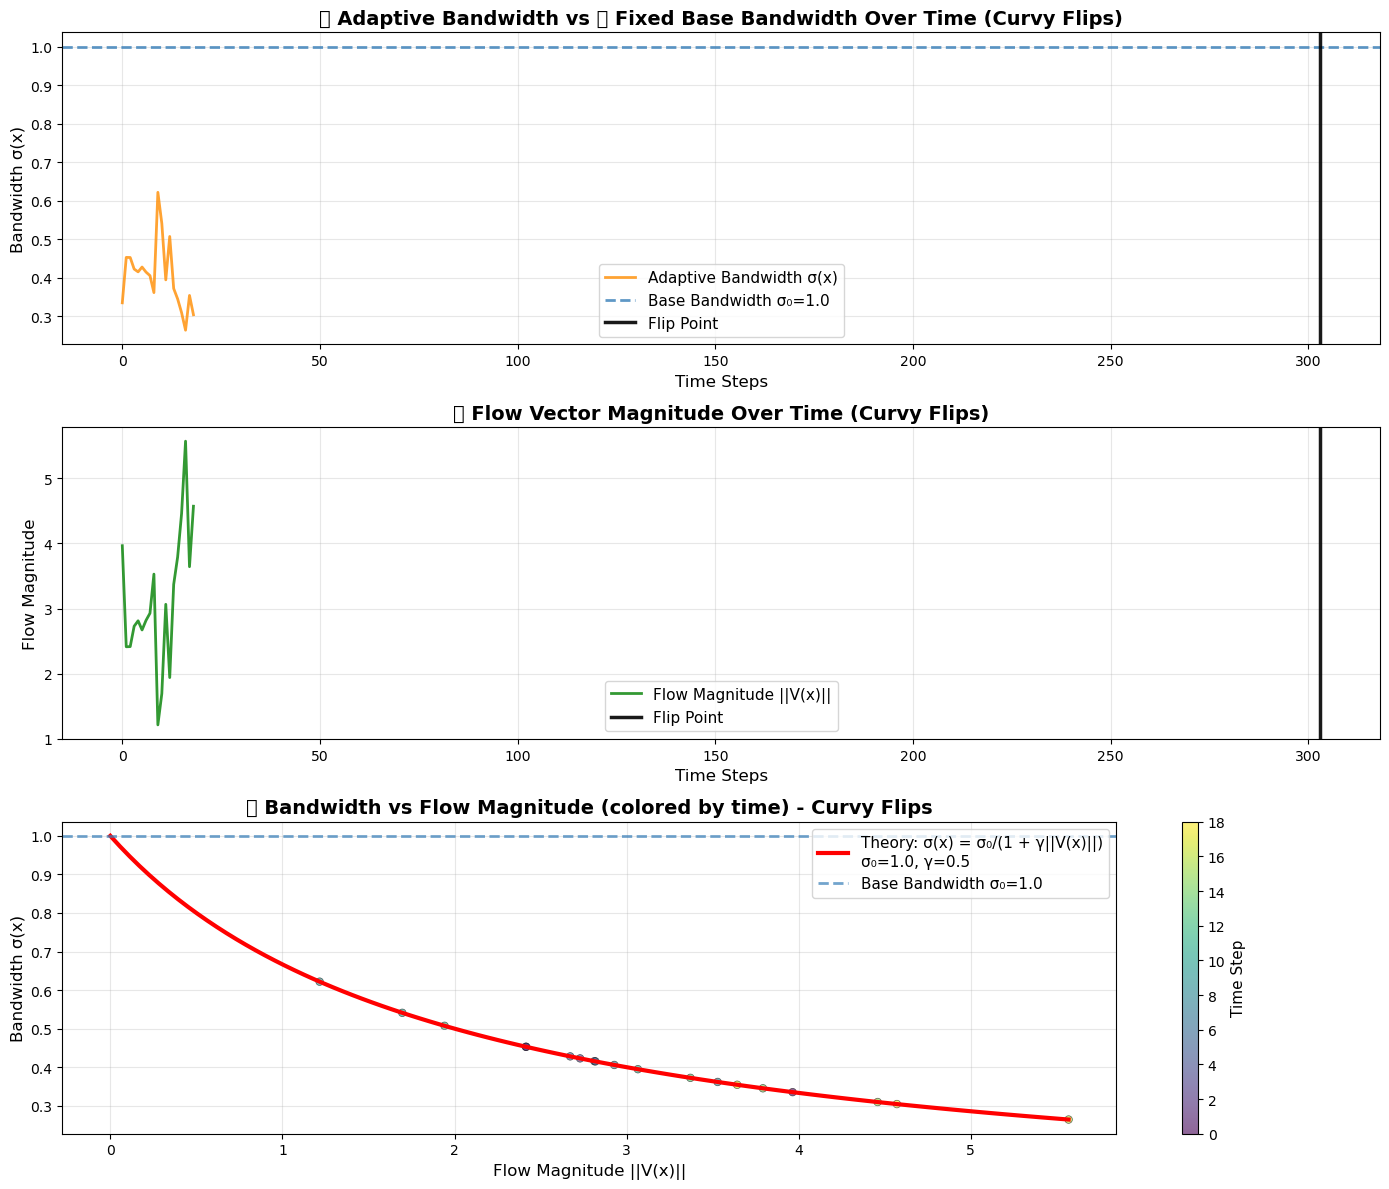


📊 Bandwidth Analysis Summary (Curvy Flips - Same Run):
   Base bandwidth σ₀: 1.000
   Flow sensitivity γ: 0.500
   Flip point: 303
   Number of stimulation events: 0

   Before flip:
      Mean bandwidth: 0.4056
      Std bandwidth: 0.0842
      Mean flow magnitude: 3.1371

   After flip:
      Mean bandwidth: nan
      Std bandwidth: nan
      Mean flow magnitude: nan

Bandwidth analysis visualization for curvy flips completed successfully!


/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/patriciobarber/anaconda3/envs/adaptive_latents/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered

In [196]:
# Visualize Bandwidth Analysis for Curvy Flips (Same Run)

print("Creating bandwidth analysis plots for CURVY FLIPS (same run as prediction errors)...")

# Extract bandwidth tracking from the Adaptive regressor
sr_adaptive_flips = srs_curvy_flips['Adaptive']

# Check if bandwidth tracking is available
if not hasattr(sr_adaptive_flips.stim_reg, 'bandwidth_history'):
    print("ERROR: Bandwidth tracking not available. Make sure to use AdaptiveMultiKernelRegressorWithTracking.")
else:
    # Extract bandwidth and flow data
    bandwidth_history_flips = np.array(sr_adaptive_flips.stim_reg.bandwidth_history)
    flow_magnitude_history_flips = np.array(sr_adaptive_flips.stim_reg.flow_magnitude_history)
    
    # Get the actual experiment length from the data
    n_experiment_steps_flips = len(stim_curvy_flips)
    print(f"Experiment length: {n_experiment_steps_flips} time steps")
    print(f"Bandwidth history length: {len(bandwidth_history_flips)} entries")
    
    # Trim bandwidth history to match experiment length if needed
    if len(bandwidth_history_flips) > n_experiment_steps_flips:
        print(f"Trimming bandwidth history from {len(bandwidth_history_flips)} to {n_experiment_steps_flips}")
        bandwidth_history_flips = bandwidth_history_flips[:n_experiment_steps_flips]
        flow_magnitude_history_flips = flow_magnitude_history_flips[:n_experiment_steps_flips]
    
    time_steps_flips = np.arange(len(bandwidth_history_flips))
    
    # Extract stimulation times
    stim_times_flips = []
    stim_data_array_flips = np.array(stim_curvy_flips.data)
    for i in range(min(len(stim_data_array_flips), len(bandwidth_history_flips))):
        if np.any(stim_data_array_flips[i] != 0):
            stim_times_flips.append(i)
    
    # Create figure with 3 subplots
    fig_flips_bw, (ax1_f, ax2_f, ax3_f) = plt.subplots(3, 1, figsize=(14, 12))
    
    # Plot 1: Bandwidth over time
    ax1_f.plot(time_steps_flips, bandwidth_history_flips, 'darkorange', linewidth=2, 
              label='Adaptive Bandwidth σ(x)', alpha=0.8)
    ax1_f.axhline(y=sr_adaptive_flips.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
                 linewidth=2, alpha=0.8, label=f'Base Bandwidth σ₀={sr_adaptive_flips.stim_reg.sigma_0}')
    
    # Add vertical black line at flip point
    ax1_f.axvline(x=flip_point, color='black', linestyle='-', 
                 linewidth=2.5, label='Flip Point', alpha=0.9, zorder=10)
    
    # Add stimulation event markers
    if stim_times_flips:
        for i, st in enumerate(stim_times_flips):
            if i == 0:
                ax1_f.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1, label='Stimulation Events')
            else:
                ax1_f.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1)
    
    ax1_f.set_xlabel('Time Steps', fontsize=12)
    ax1_f.set_ylabel('Bandwidth σ(x)', fontsize=12)
    ax1_f.set_title('🟠 Adaptive Bandwidth vs 🔵 Fixed Base Bandwidth Over Time (Curvy Flips)', 
                   fontsize=14, fontweight='bold')
    ax1_f.legend(fontsize=11)
    ax1_f.grid(True, alpha=0.3)
    
    # Plot 2: Flow magnitude over time
    ax2_f.plot(time_steps_flips, flow_magnitude_history_flips, 'green', linewidth=2, 
              label='Flow Magnitude ||V(x)||', alpha=0.8)
    
    # Add vertical black line at flip point
    ax2_f.axvline(x=flip_point, color='black', linestyle='-', 
                 linewidth=2.5, label='Flip Point', alpha=0.9, zorder=10)
    
    if stim_times_flips:
        for i, st in enumerate(stim_times_flips):
            if i == 0:
                ax2_f.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1, label='Stimulation Events')
            else:
                ax2_f.axvline(x=st, color='red', alpha=0.2, linestyle='-', linewidth=1)
    
    ax2_f.set_xlabel('Time Steps', fontsize=12)
    ax2_f.set_ylabel('Flow Magnitude', fontsize=12)
    ax2_f.set_title('🟢 Flow Vector Magnitude Over Time (Curvy Flips)', fontsize=14, fontweight='bold')
    ax2_f.legend(fontsize=11)
    ax2_f.grid(True, alpha=0.3)
    
    # Plot 3: Bandwidth vs Flow Magnitude scatter
    scatter_flips = ax3_f.scatter(flow_magnitude_history_flips, bandwidth_history_flips, alpha=0.6, s=30, 
                                 c=time_steps_flips, cmap='viridis', edgecolors='black', linewidth=0.5)
    
    # Show theoretical relationship
    flow_range_flips = np.linspace(0, np.max(flow_magnitude_history_flips), 100)
    theoretical_bandwidth_flips = sr_adaptive_flips.stim_reg.sigma_0 / (1 + sr_adaptive_flips.stim_reg.gamma * flow_range_flips)
    ax3_f.plot(flow_range_flips, theoretical_bandwidth_flips, 'r-', linewidth=3, 
              label=f'Theory: σ(x) = σ₀/(1 + γ||V(x)||)\nσ₀={sr_adaptive_flips.stim_reg.sigma_0}, γ={sr_adaptive_flips.stim_reg.gamma}')
    
    # Add base bandwidth reference line
    ax3_f.axhline(y=sr_adaptive_flips.stim_reg.sigma_0, color='#377eb8ff', linestyle='--', 
                 linewidth=2, alpha=0.7, label=f'Base Bandwidth σ₀={sr_adaptive_flips.stim_reg.sigma_0}')
    
    ax3_f.set_xlabel('Flow Magnitude ||V(x)||', fontsize=12)
    ax3_f.set_ylabel('Bandwidth σ(x)', fontsize=12)
    ax3_f.set_title('🟡 Bandwidth vs Flow Magnitude (colored by time) - Curvy Flips', 
                   fontsize=14, fontweight='bold')
    ax3_f.legend(fontsize=11, loc='upper right')
    ax3_f.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar_flips = plt.colorbar(scatter_flips, ax=ax3_f)
    cbar_flips.set_label('Time Step', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Bandwidth Analysis Summary (Curvy Flips - Same Run):")
    print(f"   Base bandwidth σ₀: {sr_adaptive_flips.stim_reg.sigma_0:.3f}")
    print(f"   Flow sensitivity γ: {sr_adaptive_flips.stim_reg.gamma:.3f}")
    print(f"   Flip point: {flip_point}")
    print(f"   Number of stimulation events: {len(stim_times_flips)}")
    
    # Compare bandwidth before and after flip
    before_bandwidth = bandwidth_history_flips[:flip_point]
    after_bandwidth = bandwidth_history_flips[flip_point:]
    
    print(f"\n   Before flip:")
    print(f"      Mean bandwidth: {np.mean(before_bandwidth):.4f}")
    print(f"      Std bandwidth: {np.std(before_bandwidth):.4f}")
    print(f"      Mean flow magnitude: {np.mean(flow_magnitude_history_flips[:flip_point]):.4f}")
    
    print(f"\n   After flip:")
    print(f"      Mean bandwidth: {np.mean(after_bandwidth):.4f}")
    print(f"      Std bandwidth: {np.std(after_bandwidth):.4f}")
    print(f"      Mean flow magnitude: {np.mean(flow_magnitude_history_flips[flip_point:]):.4f}")
    
    print("\nBandwidth analysis visualization for curvy flips completed successfully!")